In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("neo.csv")
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [ ]:
df.describe()

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


In [ ]:
df.isna().sum()

,0
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0
hazardous,0


### Detección de Valores Atípicos (Outliers) mediante Diagramas de Caja

Vamos a visualizar la distribución de las características numéricas utilizando diagramas de caja para identificar valores atípicos.

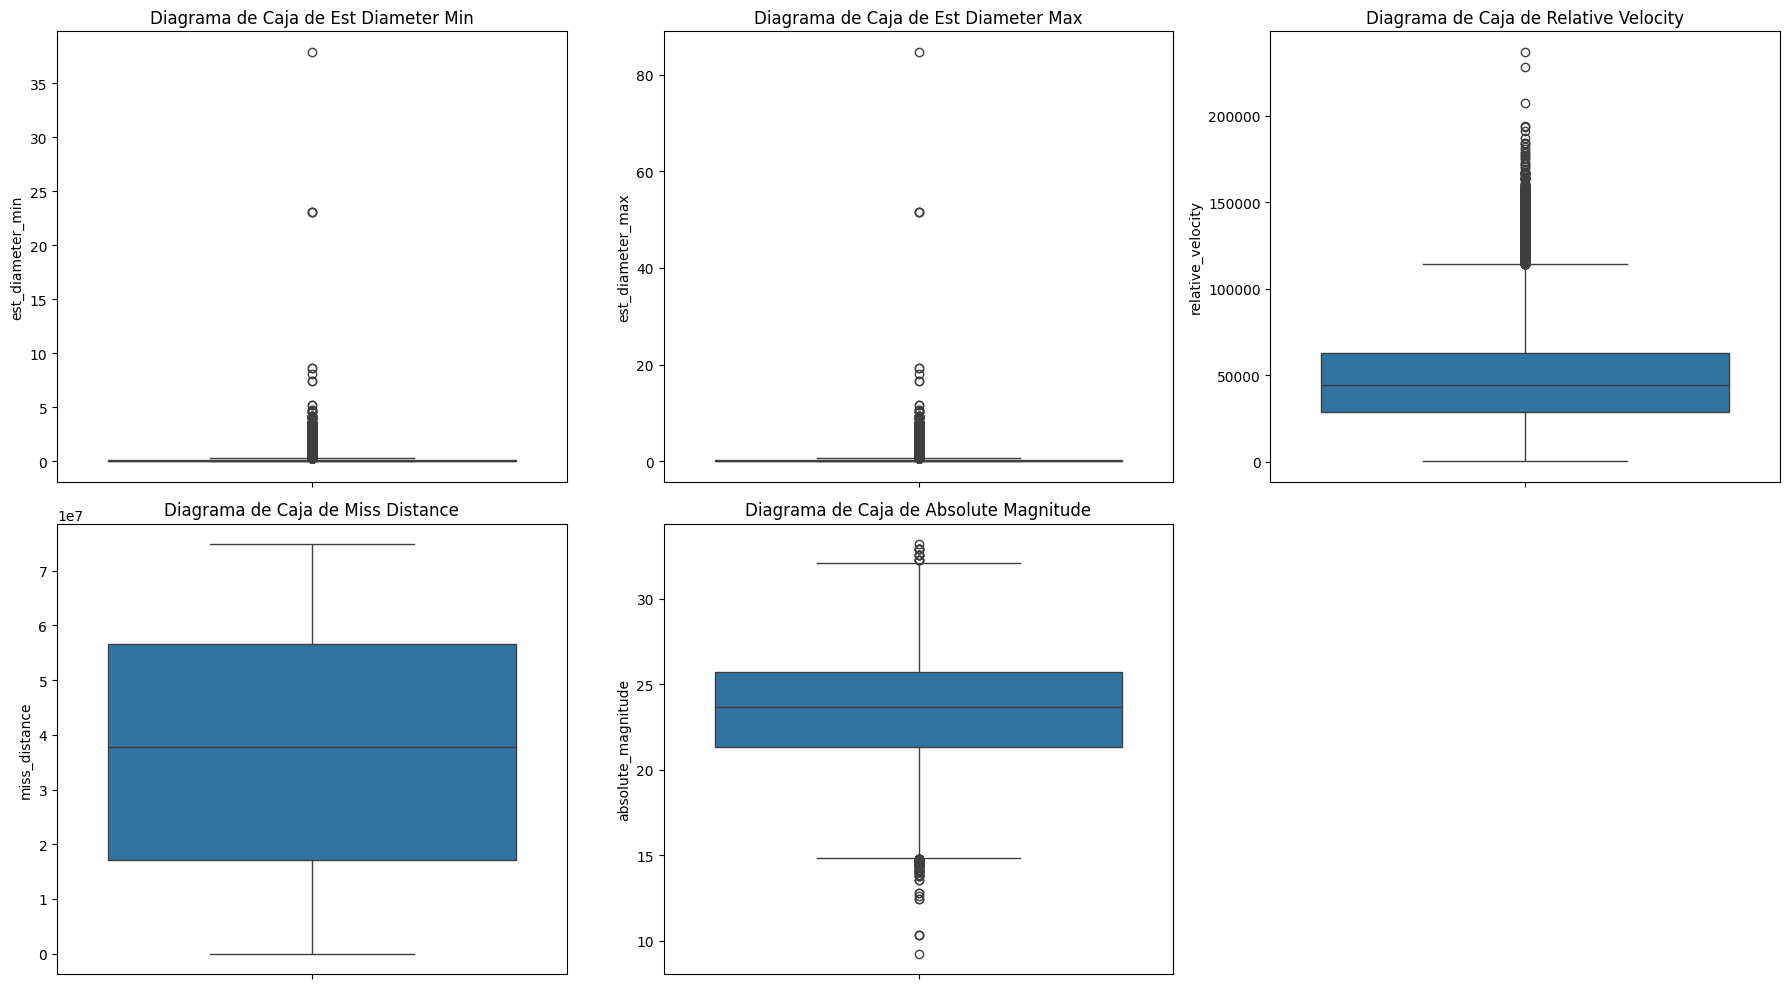

In [ ]:
numerical_cols = ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

plt.figure(figsize=(18, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed, e.g., 2 rows, 3 columns
    sns.boxplot(y=df[col])
    plt.title(f'Diagrama de Caja de {col.replace("_", " ").title()}')

plt.tight_layout()
plt.show()

Cuando analicé los diagramas de caja para las características numéricas de los NEOs (como el diámetro estimado, la velocidad o la distancia de 'casi-colisión'), vi un montón de **valores atípicos** (outliers), especialmente en los rangos más altos.

Al principio, podría pensar en eliminarlos, pero es importante entender que en datos astronómicos, estas 'anomalías' suelen ser reales. Simplemente representan NEOs que son excepcionalmente grandes o que se mueven a velocidades inusuales. Eliminarlos podría significar perder información crucial para detectar objetos realmente peligrosos.

En lugar de quitarlos, decidí **mantenerlos** porque son parte de la realidad de estos datos. Si en el futuro un modelo tiene problemas con ellos, puedo probar transformaciones de datos (como logaritmos) o usar modelos que son más robustos a los valores atípicos, como los basados en árboles. Lo clave aquí es que no son errores, sino características válidas y potencialmente muy informativas.

### Análisis de Columnas para Posible Eliminación:

Vamos a analizar si las columnas `orbiting_body`, `sentry_object`, `id` y `name` aportan información significativa para el análisis o modelado, y si conviene eliminarlas.

orbiting_body
Earth    90836
Name: count, dtype: int64
sentry_object
False    90836
Name: count, dtype: int64


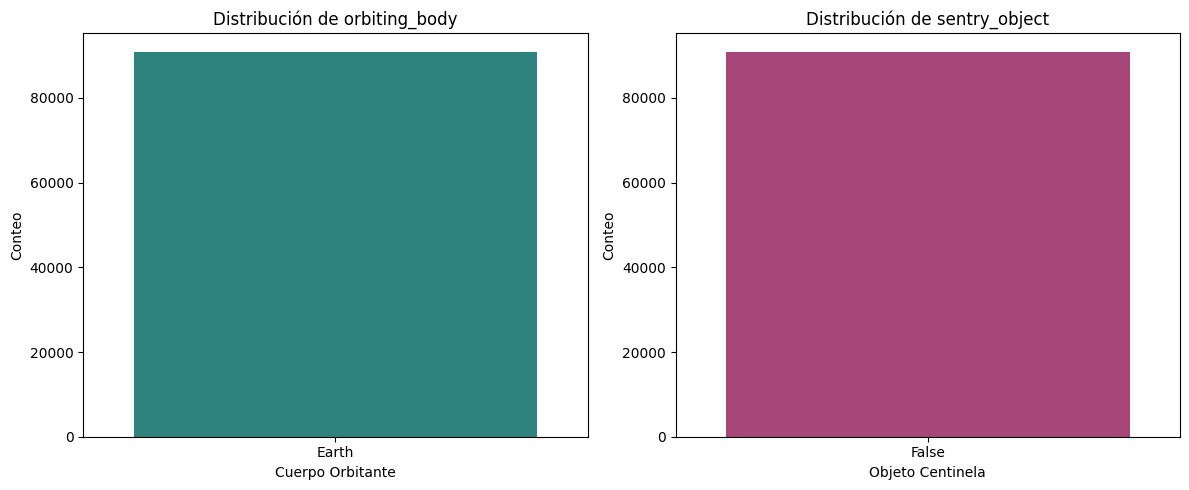

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=df['orbiting_body'], palette='viridis')
plt.title('Distribución de orbiting_body')
plt.xlabel('Cuerpo Orbitante')
plt.ylabel('Conteo')
print(df['orbiting_body'].value_counts())

plt.subplot(1, 2, 2)
sns.countplot(x=df['sentry_object'], palette='magma')
plt.title('Distribución de sentry_object')
plt.xlabel('Objeto Centinela')
plt.ylabel('Conteo')
print(df['sentry_object'].value_counts())

plt.tight_layout()
plt.show()

Al revisar las columnas, me di cuenta de que `orbiting_body` y `sentry_object` no aportan nada: todos los objetos orbitan la Tierra y ninguno es un 'objeto centinela'. Básicamente, siempre tienen el mismo valor, así que no sirven para diferenciar nada.

Por otro lado, `id` y `name` son identificadores únicos. Son como los DNI de cada objeto; nos ayudan a nombrarlos, pero un modelo de machine learning no aprende nada de un número o un texto que es diferente para cada entrada.

Por eso, para simplificar y no confundir a los modelos, decidí **eliminar estas cuatro columnas (`orbiting_body`, `sentry_object`, `id`, `name`)**. Así el conjunto de datos se queda solo con la información relevante para predecir si un objeto es peligroso o no.

### Análisis de `est_diameter_min` y `est_diameter_max`

Vamos a examinar la relación entre `est_diameter_min` y `est_diameter_max` para determinar si una de ellas podría ser eliminada.

La correlación entre 'est_diameter_min' y 'est_diameter_max' es: 1.0000


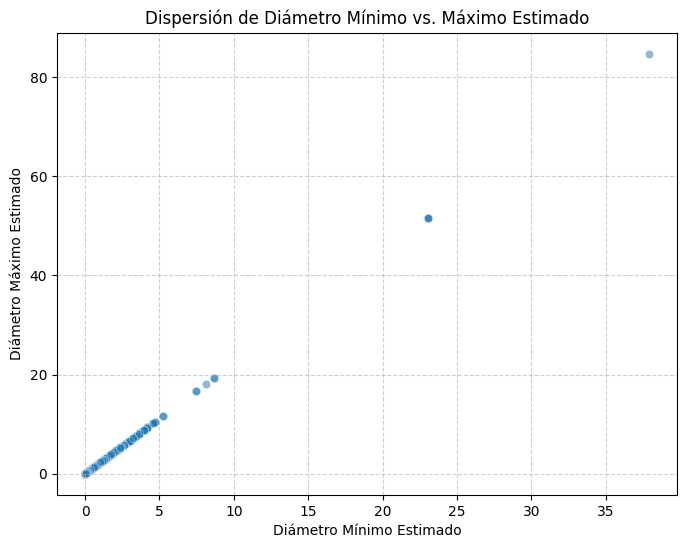

In [ ]:
correlation = df['est_diameter_min'].corr(df['est_diameter_max'])
print(f"La correlación entre 'est_diameter_min' y 'est_diameter_max' es: {correlation:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x='est_diameter_min', y='est_diameter_max', data=df, alpha=0.5)
plt.title('Dispersión de Diámetro Mínimo vs. Máximo Estimado')
plt.xlabel('Diámetro Mínimo Estimado')
plt.ylabel('Diámetro Máximo Estimado')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Al analizar los diámetros, me di cuenta de que `est_diameter_min` y `est_diameter_max` están **casi perfectamente correlacionadas**. Esto tiene sentido, ya que ambas miden el diámetro del mismo objeto, una es el mínimo y la otra el máximo.

Como son tan parecidas y redundantess, decidí que **no era conveniente mantener ambas**. En su lugar, es mejor combinarlas en una sola característica, por ejemplo, un promedio, para simplificar el modelo sin perder información.

### Eliminación de Columnas y Creación de `df_limpio`


In [ ]:
df['est_diameter_mean'] = (df['est_diameter_min'] + df['est_diameter_max']) / 2

# Columnas a eliminar
columns_to_drop = ['id', 'name', 'orbiting_body', 'sentry_object', 'est_diameter_min', 'est_diameter_max']

# Crear el DataFrame limpio
df_limpio = df.drop(columns=columns_to_drop)

# Mostrar las primeras filas del nuevo DataFrame
print("DataFrame df_limpio después de eliminar columnas y añadir 'est_diameter_mean':")
display(df_limpio.head())

DataFrame df_limpio después de eliminar columnas y añadir 'est_diameter_mean':


,relative_velocity,miss_distance,absolute_magnitude,hazardous,est_diameter_mean
0,13569.249224,5.483974e+07,16.73,False,1.938843
1,73588.726663,6.143813e+07,20.00,True,0.430073
2,114258.692129,4.979872e+07,17.83,False,1.168268
3,24764.303138,2.543497e+07,22.20,False,0.156150
4,42737.733765,4.627557e+07,20.09,True,0.412613


Basándonos en los análisis anteriores, procederemos a eliminar las columnas que no aportan información significativa o que generan redundancia (`orbiting_body`, `sentry_object`, `id`, `name`, `est_diameter_min`, `est_diameter_max`). Crearemos una nueva columna `est_diameter_mean` para representar el diámetro y luego construiremos un DataFrame limpio (`df_limpio`) con las columnas restantes.

In [ ]:
df_limpio.shape

(90836, 5)

### Conversión de la Columna `hazardous` a Formato Numérico


In [ ]:
# Convertir la columna 'hazardous' de booleano a entero (0 y 1)
df_limpio['hazardous'] = df_limpio['hazardous'].astype(int)

# Mostrar las primeras filas del DataFrame limpio con la columna 'hazardous' convertida
print("DataFrame df_limpio después de convertir 'hazardous' a numérico:")
display(df_limpio.head())

DataFrame df_limpio después de convertir 'hazardous' a numérico:


,relative_velocity,miss_distance,absolute_magnitude,hazardous,est_diameter_mean
0,13569.249224,5.483974e+07,16.73,0,1.938843
1,73588.726663,6.143813e+07,20.00,1,0.430073
2,114258.692129,4.979872e+07,17.83,0,1.168268
3,24764.303138,2.543497e+07,22.20,0,0.156150
4,42737.733765,4.627557e+07,20.09,1,0.412613


Convertiremos la columna booleana `hazardous` (Peligroso) a un formato numérico (0 para `False`, 1 para `True`) para que sea más fácil de usar en modelos de aprendizaje automático.

In [ ]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   relative_velocity   90836 non-null  float64
 1   miss_distance       90836 non-null  float64
 2   absolute_magnitude  90836 non-null  float64
 3   hazardous           90836 non-null  int64  
 4   est_diameter_mean   90836 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 3.5 MB


### Gráfico de Correlación de las Características en `df_limpio`

Ahora que hemos limpiado y preparado el DataFrame, vamos a visualizar la matriz de correlación para entender cómo se relacionan las características numéricas entre sí. Esto es útil para identificar posibles relaciones lineales y multicolinealidad.

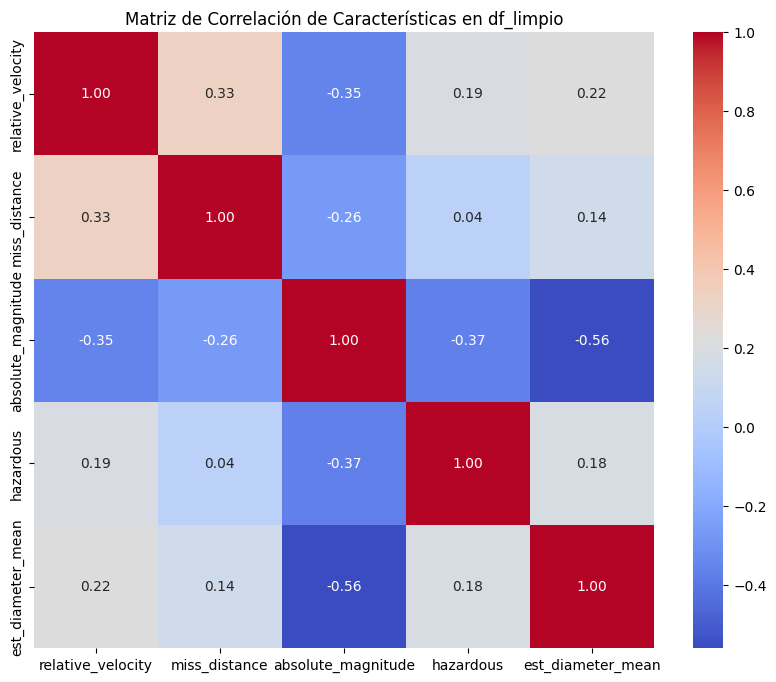

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_limpio.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Características en df_limpio')
plt.show()

Cuando observamos este **mapa de calor de correlación**, nuestro objetivo es entender cómo se relacionan las diferentes características entre sí. En esencia:

*   Si los valores están **cerca de 1 o -1**, indica una correlación lineal muy fuerte. Un 1 significa que suben o bajan juntas; un -1, que una sube mientras la otra baja.
*   Si los valores están **cerca de 0**, la correlación lineal es débil o inexistente.

**Nuestras observaciones clave son:**
*   En primer lugar, analizamos cómo se relaciona `hazardous` (nuestra variable objetivo, que nos dice si el objeto es peligroso o no) con las demás características. Esto nos da una pista sobre cuáles son los predictores más importantes.
*   También es fundamental revisar las correlaciones entre las propias características predictoras. Si encontramos dos predictores muy, muy correlacionados (por ejemplo, por encima de 0.8 o por debajo de -0.8), esto podría señalar un problema de **multicolinealidad**. Esta situación puede afectar a algunos modelos de Machine Learning, por lo que es algo que debemos tener en cuenta.

##Este pairplot nos permite visualizar rápidamente las distribuciones individuales de cada característica y sus relaciones por pares, diferenciando los objetos hazardous (peligrosos) de los no peligrosos.

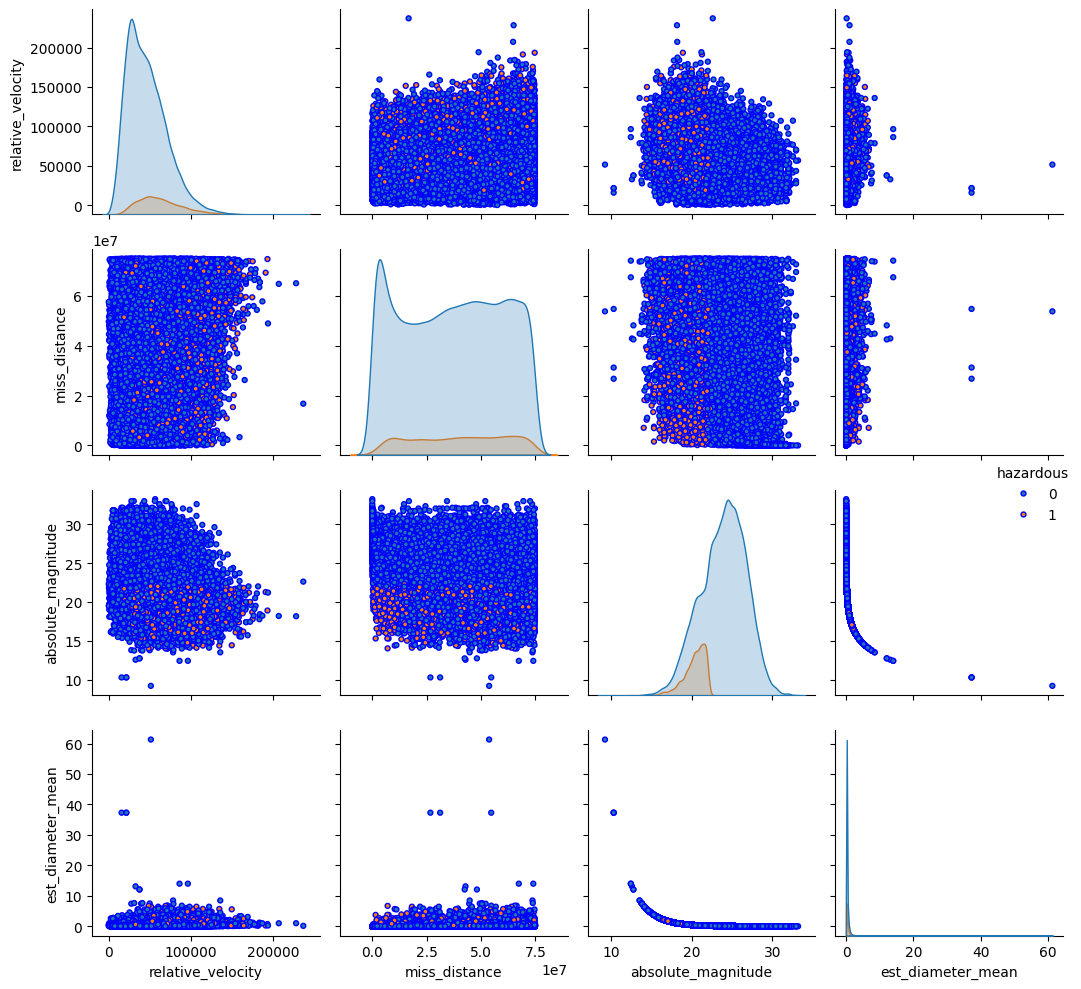

In [ ]:
sns.pairplot(data=df_limpio,
             diag_kind="kde",
             markers=".",
             plot_kws=dict(s=50, edgecolor="b", linewidth=1),
             hue="hazardous",
             vars=["relative_velocity",
                   "miss_distance",
                   "absolute_magnitude",
                   "est_diameter_mean"],
             diag_kws=dict(fill=True))

plt.tight_layout()
plt.show()

### Análisis del Pairplot

**Observaciones Clave:**

1.  **Distribuciones y Relaciones:**
    *   Se observa que los objetos `hazardous` (representados en naranja) tienden a tener una **`absolute_magnitude` más baja y un `est_diameter_mean` más alto**, lo que indica que los objetos más grandes son más propensos a ser peligrosos.
    *   Existe una **fuerte correlación negativa entre `est_diameter_mean` y `absolute_magnitude`**, lo cual es coherente (objetos más grandes tienen menor magnitud absoluta).
    *   Para `relative_velocity` y `miss_distance`, las distribuciones de objetos peligrosos y no peligrosos **se superponen más**, y sus relaciones con otras variables no muestran una separación tan clara como la del tamaño.

**En resumen:**

*   El `pairplot` destaca que el **tamaño del objeto (medido por `est_diameter_mean` y `absolute_magnitude`) es el factor más distintivo** para diferenciar objetos peligrosos. Los objetos más grandes tienen una mayor probabilidad de ser `hazardous`.
*   Las variables `relative_velocity` y `miss_distance` son relevantes, pero su influencia en la peligrosidad es menos directa y más compleja de discernir visualmente en este tipo de gráfico.

##Gráficos de Violín para Características Numéricas vs. `hazardous`

Estos gráficos de violín nos permitirán ver la distribución de cada característica numérica y cómo difiere entre los objetos que son `hazardous` (peligrosos) y los que no lo son.

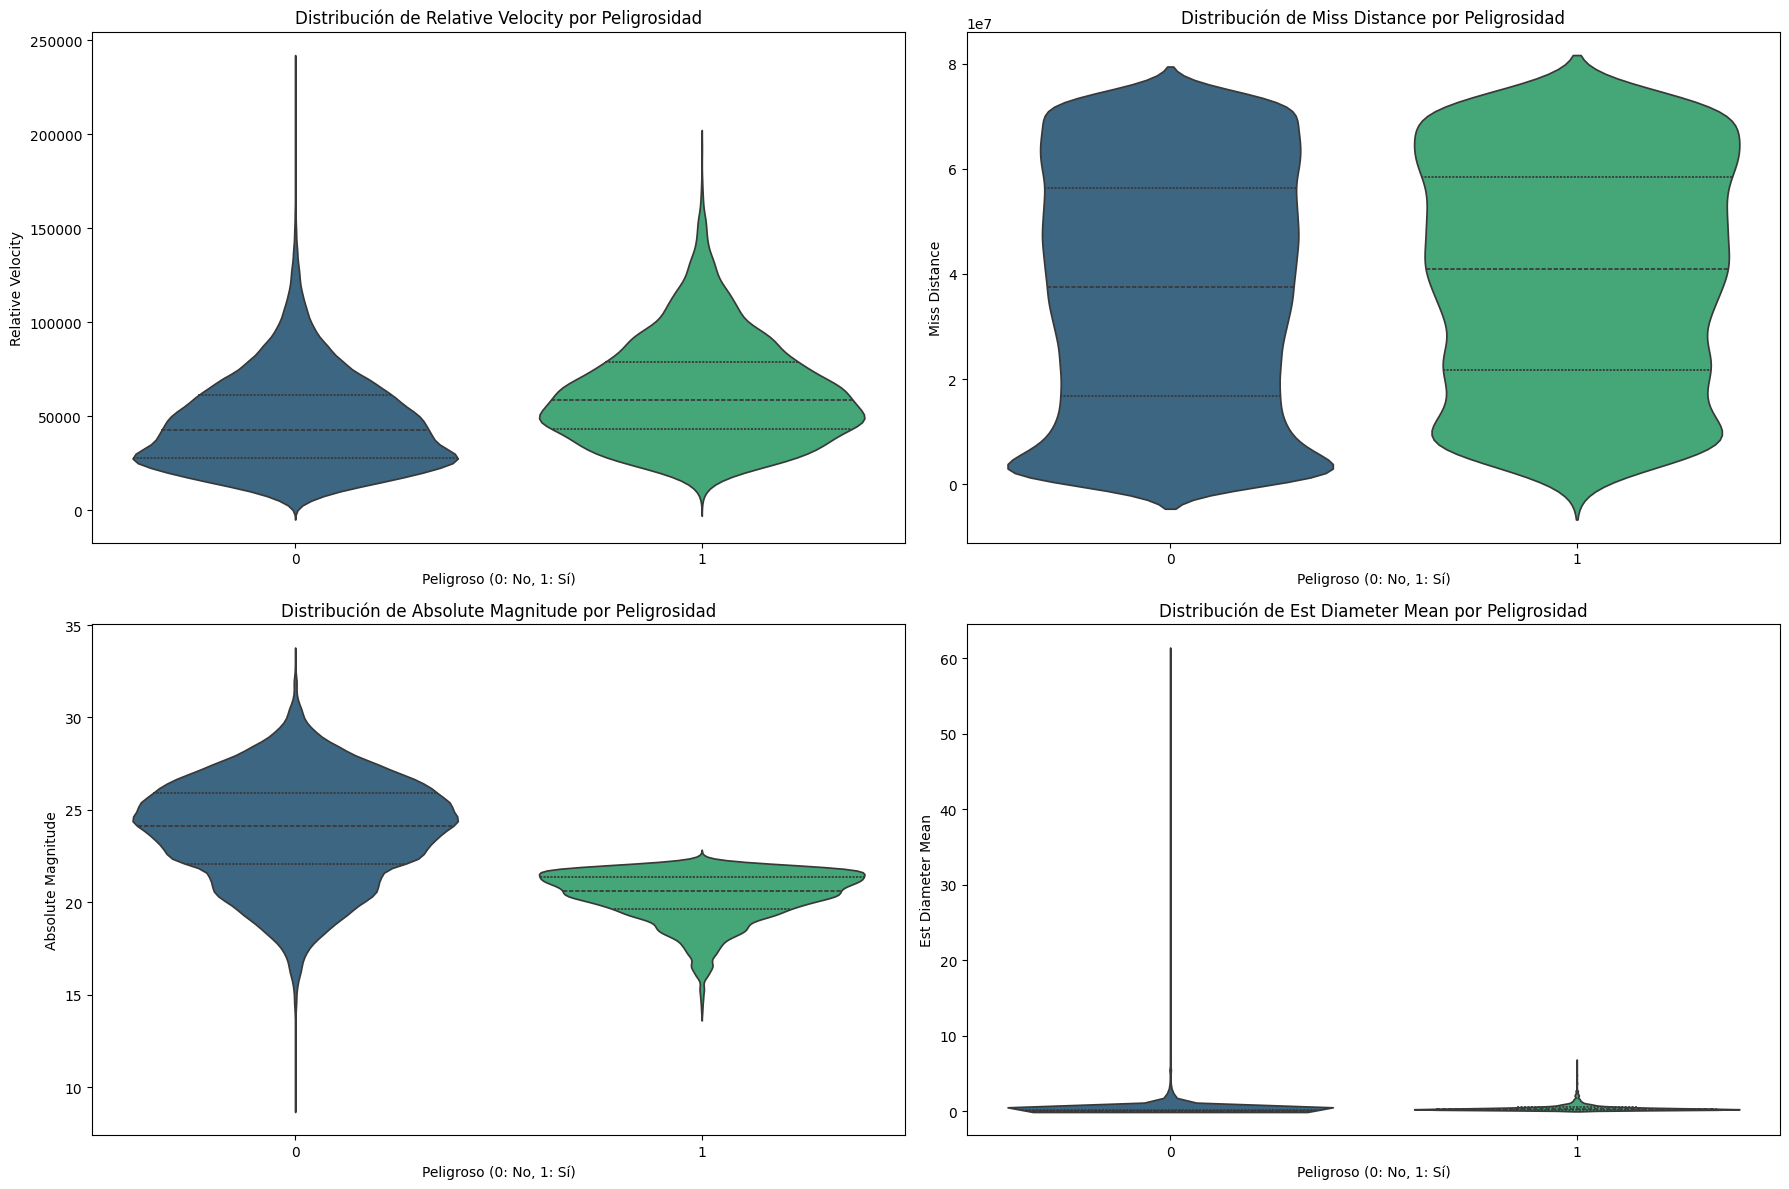

In [ ]:
plt.figure(figsize=(18, 12))

numerical_features = ['relative_velocity', 'miss_distance', 'absolute_magnitude', 'est_diameter_mean']

for i, col in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1) # Ajustar la cuadrícula de subplots a 2 filas, 2 columnas
    sns.violinplot(x='hazardous', y=col, data=df_limpio, palette='viridis', inner='quartile')
    plt.title(f'Distribución de {col.replace("_", " ").title()} por Peligrosidad')
    plt.xlabel('Peligroso (0: No, 1: Sí)')
    plt.ylabel(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

### Interpretación de los Gráficos de Violín:

Los gráficos de violín nos proporcionan una visión más detallada de las distribuciones que los diagramas de caja, mostrando la densidad de probabilidad en diferentes valores para cada clase (`hazardous` o no `hazardous`).

*   **`relative_velocity`**: La distribución para objetos `hazardous` (1) parece ser ligeramente diferente, con una posible concentración en rangos de velocidad específicos, aunque existe una superposición considerable con los objetos no `hazardous` (0).
*   **`miss_distance`**: Ambas distribuciones (para objetos `hazardous` y no `hazardous`) son bastante similares. Esto sugiere que la distancia de 'casi-colisión' por sí sola podría no ser un predictor muy fuerte de peligrosidad.
*   **`absolute_magnitude`**: Se observa una clara diferencia. Los objetos `hazardous` (1) presentan una `absolute_magnitude` generalmente más baja que los no `hazardous` (0). Una magnitud absoluta más baja indica que el objeto es más brillante y, por lo tanto, generalmente más grande. Esto refuerza la idea de que el tamaño es un factor clave.
*   **`est_diameter_mean`**: En consonancia con `absolute_magnitude`, los objetos `hazardous` (1) muestran distribuciones con diámetros medios estimados significativamente más altos que los objetos no `hazardous` (0). Esta es una fuerte indicación de que el tamaño del objeto es un predictor crucial para determinar su peligrosidad.

**En resumen:** Los gráficos de violín confirman que **el tamaño del objeto** (representado por `absolute_magnitude` y `est_diameter_mean`) es un predictor diferenciador fundamental para la clasificación de NEOs como peligrosos.

##Estandarización de las Características

Como mencionamos, la estandarización es crucial para que muchos modelos de Machine Learning funcionen correctamente, especialmente aquellos basados en distancias o que asumen una distribución normal. Utilizaremos `StandardScaler` para transformar nuestras características numéricas, asegurando que tengan una media de 0 y una desviación estándar de 1.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separar características (X) y variable objetivo (y)
X = df_limpio.drop('hazardous', axis=1)
y = df_limpio['hazardous']

# Dividir los datos en conjuntos de entrenamiento y prueba (80% train, 20% test)
# Usamos stratify=y para asegurar que la proporción de clases en 'hazardous' sea la misma en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Inicializar el estandarizador
scaler = StandardScaler()

# Ajustar el estandarizador solo con los datos de entrenamiento y luego transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir los arrays NumPy escalados de nuevo a DataFrames para facilitar la visualización y el manejo
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Datos estandarizados. Primeras 5 filas del X_train escalado:")
display(X_train_scaled_df.head())
print("\nPrimeras 5 filas del X_test escalado:")
display(X_test_scaled_df.head())



Datos estandarizados. Primeras 5 filas del X_train escalado:


,relative_velocity,miss_distance,absolute_magnitude,est_diameter_mean
9798,-1.032778,0.666406,0.542623,-0.318442
57042,-1.092656,-1.186340,0.921774,-0.349530
48266,-0.566838,-0.023680,0.714965,-0.334530
52096,-0.039783,0.913336,-1.959771,1.818109
22890,-0.355302,0.109125,-0.391466,-0.124187



Primeras 5 filas del X_test escalado:


,relative_velocity,miss_distance,absolute_magnitude,est_diameter_mean
55529,-0.843605,-1.021827,2.379781,-0.389944
35751,0.645849,0.178554,-0.215678,-0.181222
18466,-1.076071,-0.879396,0.242750,-0.279894
42274,0.719682,1.377402,0.990710,-0.353678
30785,-1.056972,-1.018738,1.145818,-0.361723


### ¿Por qué Estandarización y no Normalización en Nuestro Caso?

Aquí, nuestro equipo decidió aplicar la **estandarización (`StandardScaler`)** en lugar de la normalización (`MinMaxScaler`) por varias razones clave que se ajustan mejor a nuestros datos y modelos:

1.  **Manejo de Outliers:** Como ya hemos discutido, nuestras características numéricas (especialmente el diámetro y la distancia) tienen valores atípicos significativos. La estandarización, al trabajar con la media y la desviación estándar, es menos sensible a los valores atípicos extremos que la normalización, que comprime todos los datos en un rango fijo (generalmente [0, 1]) y, por lo tanto, es muy susceptible a ellos.

2.  **Distribución de Datos:** La estandarización transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Esto es especialmente beneficioso para algoritmos que asumen una distribución gaussiana de las características o que calculan distancias (como KNN, SVM y Regresión Logística), permitiéndoles converger más rápido y rendir mejor.

3.  **Preservación de la Información de la Distribución:** Aunque los valores atípicos están presentes, son 'reales' en nuestro dominio. La estandarización ayuda a mantener la información sobre las diferencias de magnitud relativa y la forma general de la distribución de cada característica, a diferencia de la normalización que comprime la escala y puede reducir la importancia de estas diferencias.

En resumen, la estandarización nos proporciona un equilibrio adecuado para preparar nuestros datos, asegurando que los modelos basados en distancias funcionen eficazmente sin que los valores extremos distorsionen excesivamente la escala de las características.

## Entrenamiento y Evaluación de Modelos Supervisados

Ahora que nuestros datos están estandarizados, procederemos a entrenar y evaluar varios modelos de clasificación supervisados. Compararemos su rendimiento para determinar cuál es el más adecuado para predecir si un objeto cercano a la Tierra es `hazardous`.

#### 1. Regresión Logística

La Regresión Logística es un algoritmo de clasificación lineal que es simple y eficiente, y sirve como un buen punto de partida.

--- Regresión Logística ---
Accuracy: 0.9030127334776705

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     24599
           1       0.51      0.08      0.14      2652

    accuracy                           0.90     27251
   macro avg       0.71      0.54      0.54     27251
weighted avg       0.87      0.90      0.87     27251



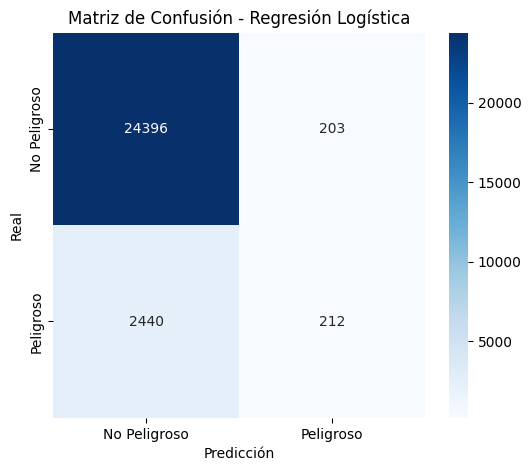

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar y entrenar el modelo de Regresión Logística
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' para datasets pequeños
log_reg_model.fit(X_train_scaled_df, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_log_reg = log_reg_model.predict(X_test_scaled_df)

# Evaluar el modelo
print("--- Regresión Logística ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

# Matriz de Confusión
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Peligroso', 'Peligroso'], yticklabels=['No Peligroso', 'Peligroso'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

#### 2. Árbol de Decisión

Los Árboles de Decisión son modelos no paramétricos que dividen el espacio de características en regiones. Son interpretables y pueden capturar relaciones no lineales.

--- Árbol de Decisión ---
Accuracy: 0.8906829107188727

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     24599
           1       0.44      0.46      0.45      2652

    accuracy                           0.89     27251
   macro avg       0.69      0.70      0.69     27251
weighted avg       0.89      0.89      0.89     27251



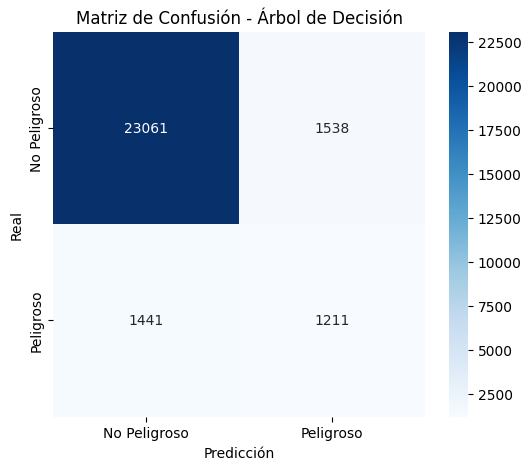

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Inicializar y entrenar el modelo de Árbol de Decisión
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled_df, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_dt = dt_model.predict(X_test_scaled_df)

# Evaluar el modelo
print("--- Árbol de Decisión ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Matriz de Confusión
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Peligroso', 'Peligroso'], yticklabels=['No Peligroso', 'Peligroso'])
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

#### 3. K-Nearest Neighbors (KNN)

KNN es un algoritmo de aprendizaje supervisado no paramétrico que se utiliza para problemas de clasificación y regresión. Se basa en la idea de que los puntos de datos que son similares entre sí están cerca en el espacio. Es sensible a la escala de las características, por lo que la estandarización previa es beneficiosa.

-- K-Nearest Neighbors (KNN) --
Accuracy: 0.908076767825034

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     24599
           1       0.58      0.20      0.30      2652

    accuracy                           0.91     27251
   macro avg       0.75      0.59      0.62     27251
weighted avg       0.89      0.91      0.89     27251



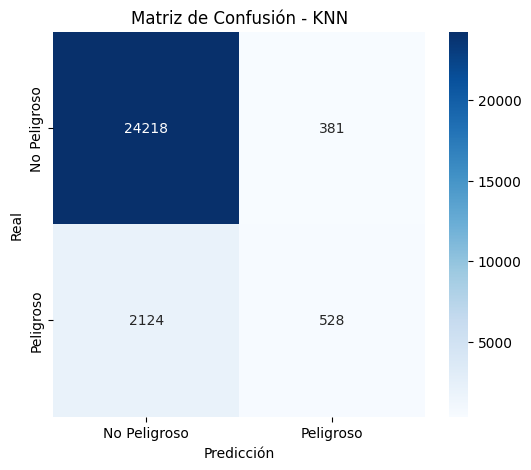

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Inicializar y entrenar el modelo KNN
# Se puede experimentar con diferentes valores de n_neighbors
knn_model = KNeighborsClassifier(n_neighbors=8) # n_neighbors es un hiperparámetro importante
knn_model.fit(X_train_scaled_df, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_knn = knn_model.predict(X_test_scaled_df)

# Evaluar el modelo
print("-- K-Nearest Neighbors (KNN) --")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Matriz de Confusión
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Peligroso', 'Peligroso'], yticklabels=['No Peligroso', 'Peligroso'])
plt.title('Matriz de Confusión - KNN')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


In [ ]:
#Configuramos matrices para almacenar la precisión de las pruebas y el entrenamiento
neighbors = np.arange(1,10)
train_accuracy =np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i,k in enumerate(neighbors):
    #
    knn = KNeighborsClassifier(n_neighbors=k)

    #
    knn.fit(X_train_scaled_df, y_train)

    #Calculamos la exactitud con entrenamiento
    train_accuracy[i] = knn.score(X_train_scaled_df, y_train)

    #Calculamos la exactitud con test
    test_accuracy[i] = knn.score(X_test_scaled_df, y_test)


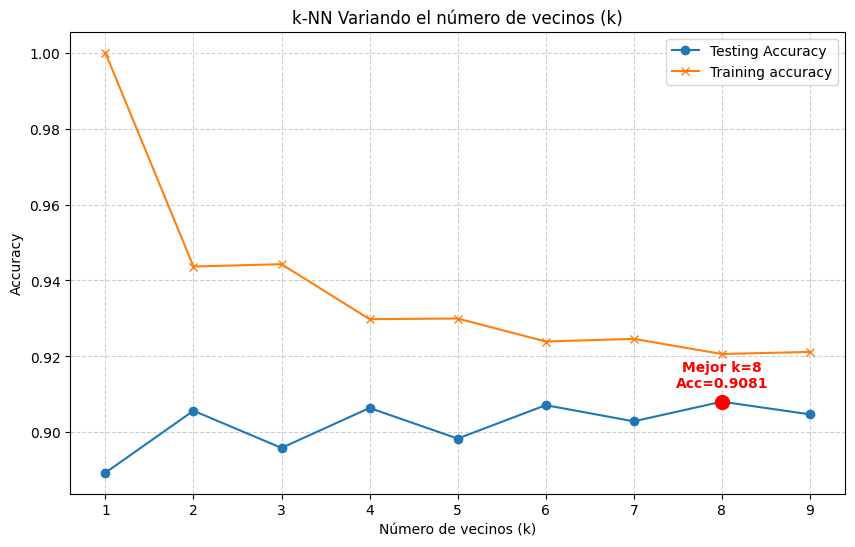

In [ ]:
#Generamos un gráfico con las iteraciones con diferentes K vs la exactitud
plt.figure(figsize=(10, 6))
plt.title('k-NN Variando el número de vecinos (k)')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy', marker='o')
plt.plot(neighbors, train_accuracy, label='Training accuracy', marker='x')
plt.legend()
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Accuracy')
plt.xticks(neighbors) # Asegurar que se muestran todos los k
plt.grid(True, linestyle='--', alpha=0.6)

# Identificar el mejor k en los datos de prueba
best_k_index = np.argmax(test_accuracy)
best_k = neighbors[best_k_index]
best_acc = test_accuracy[best_k_index]

# Resaltar el mejor punto en el gráfico
plt.plot(best_k, best_acc, 'ro', markersize=10, label=f'Mejor k: {best_k} (Acc: {best_acc:.4f})')
plt.annotate(f'Mejor k={best_k}\nAcc={best_acc:.4f}', (best_k, best_acc), textcoords="offset points", xytext=(0,10), ha='center', color='red', weight='bold')

plt.show()


#### 4. Support Vector Machine (SVM)

SVM es un potente algoritmo de clasificación que funciona bien en espacios de alta dimensión y con datos complejos. Busca encontrar el hiperplano óptimo que separe las clases en el espacio de características. Es sensible a la escala de las características.

-- Support Vector Machine (SVM) --
Accuracy: 0.9118564456350226

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     24599
           1       0.80      0.13      0.22      2652

    accuracy                           0.91     27251
   macro avg       0.86      0.56      0.59     27251
weighted avg       0.90      0.91      0.88     27251



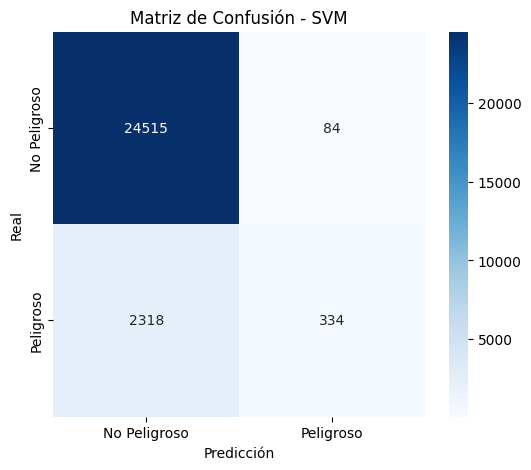

In [ ]:
from sklearn.svm import SVC

# Inicializar y entrenar el modelo SVM
# Para datasets grandes, se puede usar LinearSVC o ajustar el kernel y el parámetro C
# Aquí usamos un kernel RBF (radial basis function) por defecto
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled_df, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_svm = svm_model.predict(X_test_scaled_df)

# Evaluar el modelo
print("-- Support Vector Machine (SVM) --")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Matriz de Confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Peligroso', 'Peligroso'], yticklabels=['No Peligroso', 'Peligroso'])
plt.title('Matriz de Confusión - SVM')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

#### 5. Naive Bayes (Gaussian Naive Bayes)

Gaussian Naive Bayes es un algoritmo de clasificación basado en el teorema de Bayes con la suposición de independencia entre las características. Asume que las características siguen una distribución Gaussiana.

-- Gaussian Naive Bayes --
Accuracy: 0.863564639829731

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92     24599
           1       0.28      0.26      0.27      2652

    accuracy                           0.86     27251
   macro avg       0.60      0.60      0.60     27251
weighted avg       0.86      0.86      0.86     27251



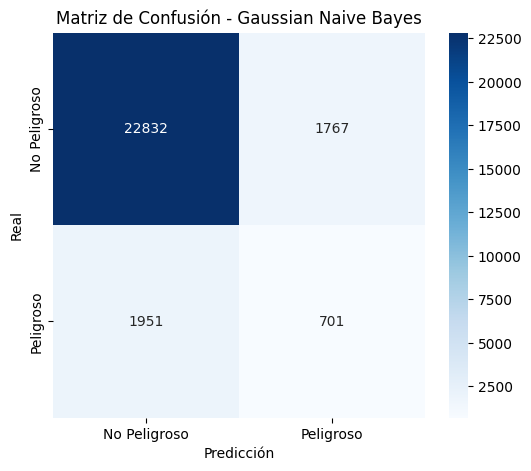

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Inicializar y entrenar el modelo Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled_df, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_nb = nb_model.predict(X_test_scaled_df)

# Evaluar el modelo
print("-- Gaussian Naive Bayes --")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

# Matriz de Confusión
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Peligroso', 'Peligroso'], yticklabels=['No Peligroso', 'Peligroso'])
plt.title('Matriz de Confusión - Gaussian Naive Bayes')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### Comparación Exhaustiva de Modelos

Ahora que hemos evaluado todos los modelos solicitados (Regresión Logística, Árbol de Decisión, Random Forest, KNN, SVM, Naive Bayes), presentaremos una tabla comparativa completa con sus métricas clave. Esto nos permitirá tener una visión global y decidir cuál es el modelo más adecuado para nuestro problema de clasificación de objetos `hazardous`.

In [ ]:
# Recopilar métricas de los informes de clasificación para todos los modelos
from sklearn.metrics import precision_score, recall_score, f1_score

model_names = [
    'Regresión Logística',
    'Árbol de Decisión',
    'KNN',
    'SVM',
    'Gaussian Naive Bayes'
]
predictions = [
    y_pred_log_reg,
    y_pred_dt,
    y_pred_knn,
    y_pred_svm,
    y_pred_nb
]

metrics = []

for i, name in enumerate(model_names):
    accuracy = accuracy_score(y_test, predictions[i])
    # Asegurarse de que pos_label=1 se usa para la clase 'Peligroso'
    precision_hazardous = precision_score(y_test, predictions[i], pos_label=1, zero_division=0)
    recall_hazardous = recall_score(y_test, predictions[i], pos_label=1, zero_division=0)
    f1_hazardous = f1_score(y_test, predictions[i], pos_label=1, zero_division=0)

    metrics.append({
        'Modelo': name,
        'Accuracy': accuracy,
        'Precision (Hazardous)': precision_hazardous,
        'Recall (Hazardous)': recall_hazardous,
        'F1-Score (Hazardous)': f1_hazardous
    })

metrics_df = pd.DataFrame(metrics)
display(metrics_df.round(4))

,Modelo,Accuracy,Precision (Hazardous),Recall (Hazardous),F1-Score (Hazardous)
0,Regresión Logística,0.9030,0.5108,0.0799,0.1382
1,Árbol de Decisión,0.8907,0.4405,0.4566,0.4484
2,KNN,0.9081,0.5809,0.1991,0.2965
3,SVM,0.9119,0.7990,0.1259,0.2176
4,Gaussian Naive Bayes,0.8636,0.2840,0.2643,0.2738


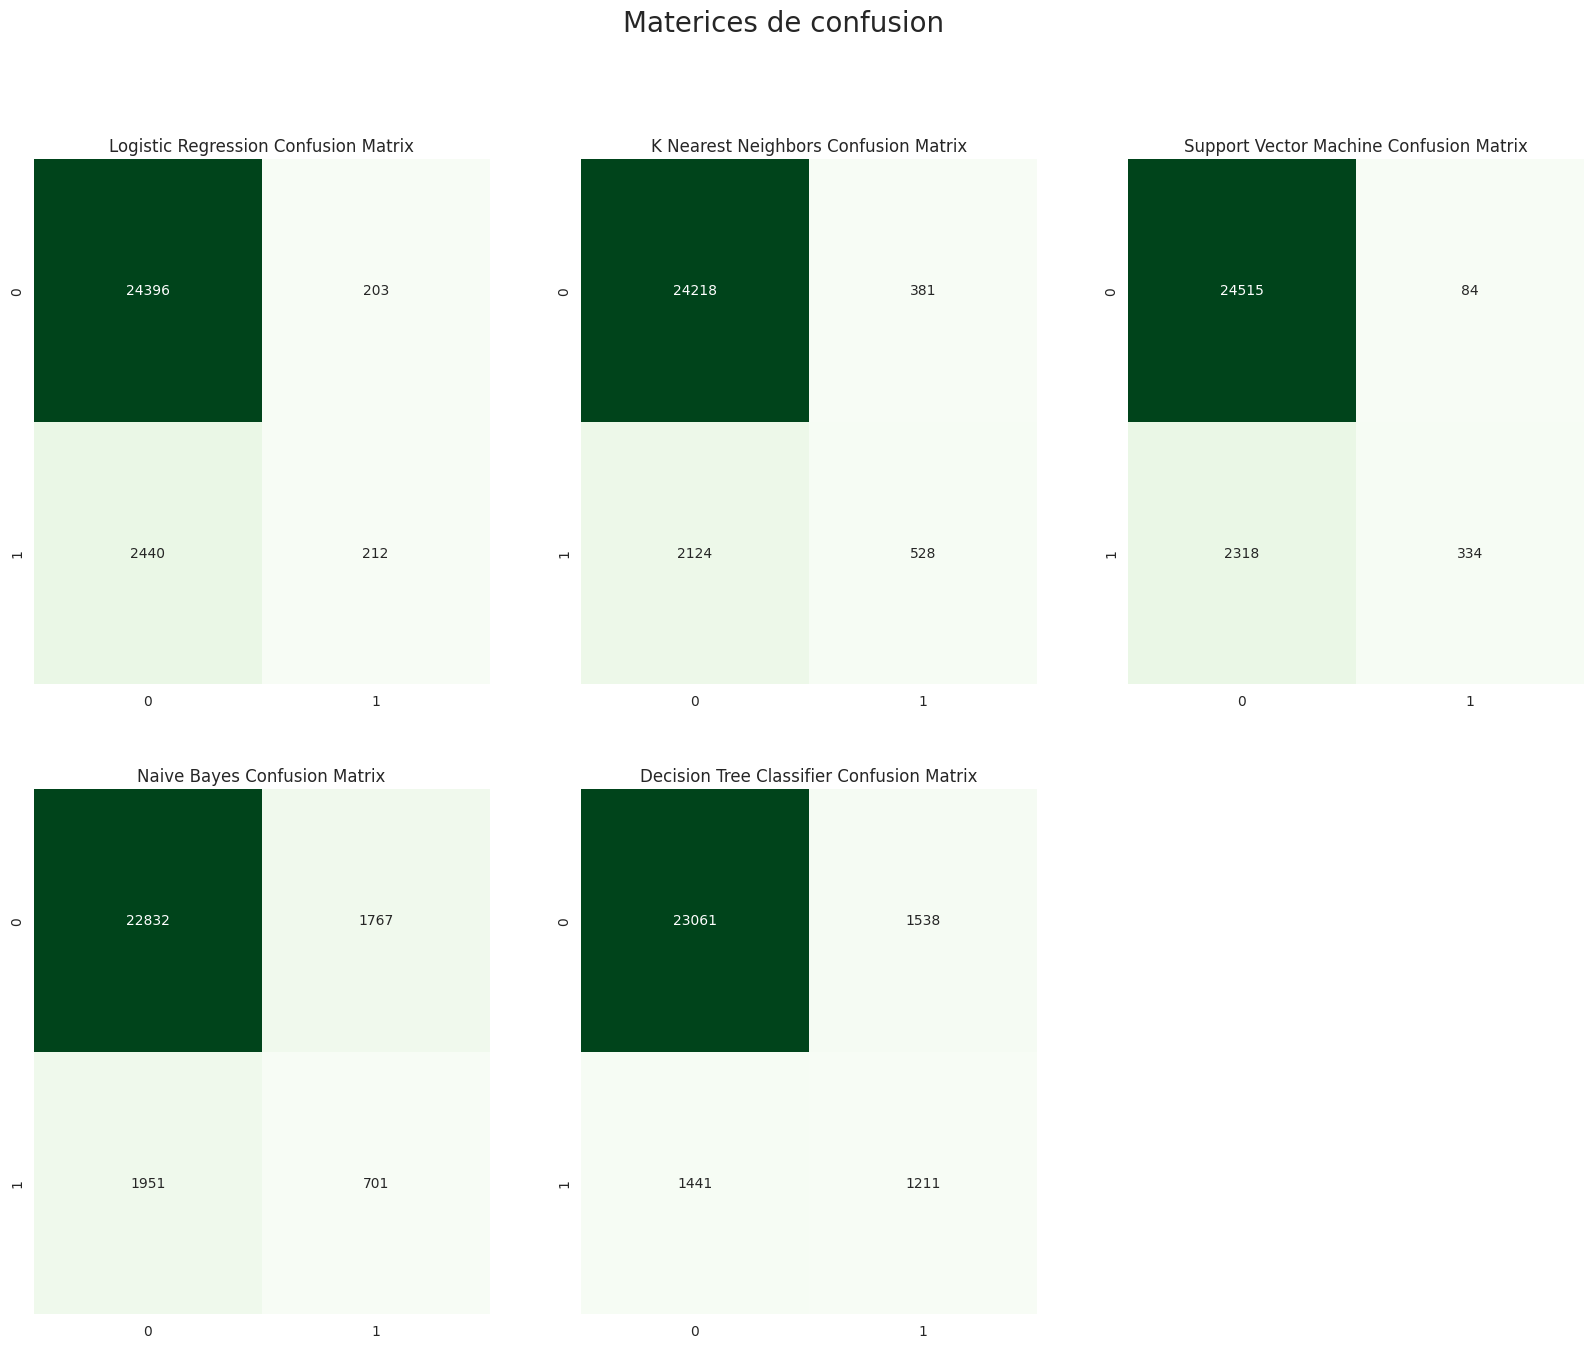

In [ ]:
plt.figure(figsize=(20,15))

plt.suptitle("Materices de confusion", fontsize=20)

plt.subplot(2,3,1)
plt.title("Logistic Regression Confusion Matrix")
sns.heatmap(cm_log_reg,cbar=False,annot=True,cmap="Greens",fmt="d")

plt.subplot(2,3,2)
plt.title("K Nearest Neighbors Confusion Matrix")
sns.heatmap(cm_knn,cbar=False,annot=True,cmap="Greens",fmt="d")

plt.subplot(2,3,3)
plt.title("Support Vector Machine Confusion Matrix")
sns.heatmap(cm_svm,cbar=False,annot=True,cmap="Greens",fmt="d")

plt.subplot(2,3,4)
plt.title("Naive Bayes Confusion Matrix")
sns.heatmap(cm_nb,cbar=False,annot=True,cmap="Greens",fmt="d")

plt.subplot(2,3,5)
plt.title("Decision Tree Classifier Confusion Matrix")
sns.heatmap(cm_dt,cbar=False,annot=True,cmap="Greens",fmt="d")

plt.show()

Basado en esta comparación exhaustiva, revisemos los modelos que se ajustan a lo visto en clase:

*   **Regresión Logística:** Ofrece una precisión moderada para la clase 'Peligroso' (51%), pero su recall es extremadamente bajo (alrededor del 8%), lo que significa que detecta muy pocos objetos peligrosos reales.

*   **Árbol de Decisión:** Destaca por tener el recall más alto (casi 46%) para la clase 'Peligroso', identificando una mayor proporción de objetos realmente peligrosos. Su precisión es moderada (alrededor del 44%), ofreciendo un buen equilibrio general (F1-Score más alto de 0.4484). Aunque puede ser propenso al sobreajuste si no se ajustan sus parámetros, en este momento parece ser el modelo más prometedor para capturar objetos peligrosos, logrando el mejor balance entre precisión y exhaustividad. **Por lo cual nos quedaremos con este.**

*   **KNN (K-Nearest Neighbors):** Presenta un recall bajo (casi 20%) para la clase 'Peligroso', lo que indica que no logra identificar muchos de los objetos realmente peligrosos. Aunque su precisión es relativamente buena (casi 58%), su capacidad para encontrar casos positivos es limitada.

*   **SVM (Support Vector Machine):** Logra la precisión más alta (casi 80%) para la clase 'Peligroso', lo que significa que cuando clasifica algo como peligroso, es muy probable que lo sea. Sin embargo, su recall es muy bajo (alrededor del 13%), lo que lo hace propenso a pasar por alto muchos objetos peligrosos reales.

*   **Gaussian Naive Bayes:** Muestra el rendimiento más bajo en precisión (alrededor del 28%) y un recall bajo (alrededor del 26%) para la clase 'Peligroso' en comparación con los otros modelos, lo que sugiere que no es el más adecuado para esta tarea.

##Hiperparametros


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import f1_score
from sklearn import model_selection

accuracies ={}
means={}
randoms={}

####Regresion logistica

#####RandomizedSearchCV

In [ ]:
lr_params_random = {'penalty' : ['l1','l2', 'elasticnet','none'],
              'C' : range(1,7),
            'solver' :['newton-cg','lbfgs','liblinear','sag','saga'],
             'max_iter' : [100,200],
             'multi_class' : ['ovr','multinomial']
   }

lr=LogisticRegression()
lr_randomcv_model=RandomizedSearchCV(estimator=lr, param_distributions=lr_params_random, n_iter=100, cv=5, scoring='accuracy', n_jobs=-1, verbose=2).fit(X_train,y_train)
print(lr_randomcv_model.best_params_)
print('rf_randomcv_model accuracy score = {}'.format(lr_randomcv_model.best_score_))
random=lr_randomcv_model.best_score_*100
randoms['Logistic Regression Randomized']=random

Fitting 5 folds for each of 100 candidates, totalling 500 fits
{'solver': 'saga', 'penalty': 'l2', 'multi_class': 'ovr', 'max_iter': 100, 'C': 6}
rf_randomcv_model accuracy score = 0.9026814500275222


#####GridSearchCv

In [ ]:
lr_params = {'penalty' : ['l1','l2', 'elasticnet','none'],
              'C' : range(1,7),
            'solver' :['newton-cg','lbfgs','liblinear','sag','saga'],
             'max_iter' : [100,200],
             'multi_class' : ['ovr','multinomial']
   }

lr=LogisticRegression()
lr_gridcv_model=GridSearchCV(estimator=lr, param_grid=lr_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=2).fit(X_train,y_train)
print(lr_gridcv_model.best_params_)
print('rf_gridcv_model accuracy score = {}'.format(lr_gridcv_model.best_score_))
acc=lr_gridcv_model.best_score_*100
accuracies['Logistic Regression Grid']=acc

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
{'C': 1, 'max_iter': 100, 'multi_class': 'ovr', 'penalty': 'l1', 'solver': 'saga'}
rf_gridcv_model accuracy score = 0.9026814500275222


#####CrossValidation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression

# Usar los mejores parámetros encontrados durante RandomizedSearchCV
best_params = {'solver': 'saga', 'penalty': 'l2', 'multi_class': 'multinomial', 'max_iter': 100, 'C': 1}

# Inicializar el modelo de Regresión Logística con los mejores parámetros
log_reg_cv_model = LogisticRegression(**best_params, random_state=42)

# Definir la estrategia de validación cruzada (KFold)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Realizar la validación cruzada en los datos de entrenamiento escalados
cv_results = cross_val_score(log_reg_cv_model, X_train_scaled_df, y_train, cv=kfold, scoring='accuracy')

print("Resultados de la validación cruzada (accuracy para cada fold):", cv_results)
print(f"Precisión media de la validación cruzada: {cv_results.mean()*100:.2f}%")

mean = cv_results.mean()*100
means['Logistic Regression Cross Validation Optimized'] = mean

Resultados de la validación cruzada (accuracy para cada fold): [0.90312181 0.90296454 0.90257136 0.90036958 0.90060549]
Precisión media de la validación cruzada: 90.19%


####Arbol de decision

#####RandomizedSearchCV

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

# Definir el espacio de búsqueda de hiperparámetros para el Árbol de Decisión
dt_params_random = {
   'max_depth': range(1,20),
   'max_features': range(1,20),
   'min_samples_leaf': range(1,20),
   'max_leaf_nodes' : range(1,20)
}

# Inicializar el modelo de Árbol de Decisión
dt = DecisionTreeClassifier(random_state=42)

# Inicializar RandomizedSearchCV
dt_randomcv_model = RandomizedSearchCV(estimator=dt,
                                       param_distributions=dt_params_random,
                                       n_iter=100, # Número de combinaciones a probar
                                       cv=5, # 5-fold cross-validation
                                       scoring='accuracy',
                                       n_jobs=-1, # Usar todos los cores disponibles
                                       verbose=2)

# Ajustar RandomizedSearchCV a los datos de entrenamiento escalados
dt_randomcv_model.fit(X_train_scaled_df, y_train)

# Imprimir los mejores parámetros y el mejor score
print("Mejores parámetros para el Árbol de Decisión:", dt_randomcv_model.best_params_)
print(f"Mejor score (accuracy) de RandomizedSearchCV para el Árbol de Decisión: {dt_randomcv_model.best_score_:.4f}")

# Guardar el mejor score
random_score = dt_randomcv_model.best_score_ * 100
randoms['Decision Tree Randomized'] = random_score

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Mejores parámetros para el Árbol de Decisión: {'min_samples_leaf': 10, 'max_leaf_nodes': 18, 'max_features': 2, 'max_depth': 9}
Mejor score (accuracy) de RandomizedSearchCV para el Árbol de Decisión: 0.9119


#####GridSearchCV

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Definir el espacio de búsqueda de hiperparámetros para el Árbol de Decisión
# RANGOS REDUCIDOS Y FOCALIZADOS PARA UNA EJECUCIÓN RÁPIDA
dt_params_grid = {
    'max_depth': [5, 6, 7],
    'max_features': [1, 2, 3],
    'min_samples_leaf': [1, 2, 3],
    'max_leaf_nodes' : [15, 16, 17]
}

# Inicializar el modelo de Árbol de Decisión
dt = DecisionTreeClassifier(random_state=42)

# Inicializar GridSearchCV
dt_gridcv_model = GridSearchCV(estimator=dt,
                              param_grid=dt_params_grid,
                              cv=5,
                              scoring='accuracy',
                              n_jobs=-1,
                              verbose=2)

# Ajustar GridSearchCV a los datos de entrenamiento escalados
dt_gridcv_model.fit(X_train_scaled_df, y_train)

# Imprimir los mejores parámetros y el mejor score
print("Mejores parámetros para el Árbol de Decisión:", dt_gridcv_model.best_params_)
print(f"Mejor score (accuracy) de GridSearchCV para el Árbol de Decisión: {dt_gridcv_model.best_score_:.4f}")

# Guardar el mejor score
acc = dt_gridcv_model.best_score_ * 100
accuracies['Decision Tree Grid'] = acc

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Mejores parámetros para el Árbol de Decisión: {'max_depth': 6, 'max_features': 2, 'max_leaf_nodes': 16, 'min_samples_leaf': 1}
Mejor score (accuracy) de GridSearchCV para el Árbol de Decisión: 0.9120


#####Cross Validation

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Usar los mejores parámetros encontrados durante RandomizedSearchCV para Decision Tree
best_dt_params = dt_randomcv_model.best_params_

# Inicializar el modelo de Árbol de Decisión con los mejores parámetros
dt_cv_model = DecisionTreeClassifier(**best_dt_params, random_state=42)

# Definir la estrategia de validación cruzada (KFold)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Realizar la validación cruzada en los datos de entrenamiento escalados
cv_results_dt = cross_val_score(dt_cv_model, X_train_scaled_df, y_train, cv=kfold, scoring='accuracy')

print("Resultados de la validación cruzada (accuracy para cada fold) del Árbol de Decisión:", cv_results_dt)
print(f"Precisión media de la validación cruzada del Árbol de Decisión: {cv_results_dt.mean()*100:.2f}%")

mean_dt = cv_results_dt.mean()*100
means['Decision Tree Cross Validation Optimized'] = mean_dt

Resultados de la validación cruzada (accuracy para cada fold) del Árbol de Decisión: [0.90972714 0.91247936 0.91169301 0.9112212  0.91059212]
Precisión media de la validación cruzada del Árbol de Decisión: 91.11%


#### K-Nearest Neighbors (KNN)

##### RandomizedSearchCV para KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV

# Definir el espacio de búsqueda de hiperparámetros para KNN
knn_params_random = {
    'n_neighbors' : range(1,10),
    'weights' : ['uniform', 'distance'],
    'algorithm' : ['auto','ball_tree','kd_tree','brute'],
    'p' : [1,2]
}

# Inicializar el modelo KNN
knn = KNeighborsClassifier()

# Inicializar RandomizedSearchCV
knn_randomcv_model = RandomizedSearchCV(estimator=knn,
                                        param_distributions=knn_params_random,
                                        n_iter=100, # Número de combinaciones a probar
                                        cv=5, # 5-fold cross-validation
                                        scoring='accuracy',
                                        n_jobs=-1, # Usar todos los cores disponibles
                                        verbose=2,
                                        random_state=42)

# Ajustar RandomizedSearchCV a los datos de entrenamiento escalados
knn_randomcv_model.fit(X_train_scaled_df, y_train)

# Imprimir los mejores parámetros y el mejor score
print("Mejores parámetros para KNN:", knn_randomcv_model.best_params_)
print("Mejor score (accuracy) de RandomizedSearchCV para KNN: {}" .format(knn_randomcv_model.best_score_))

# Guardar el mejor score
random_score_knn = knn_randomcv_model.best_score_ * 100
randoms['KNN Randomized'] = random_score_knn

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Mejores parámetros para KNN: {'weights': 'uniform', 'p': 2, 'n_neighbors': 8, 'algorithm': 'ball_tree'}
Mejor score (accuracy) de RandomizedSearchCV para KNN: 0.9065188330581112


##### GridSearchCV para KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Definir el espacio de búsqueda de hiperparámetros para KNN (más enfocado alrededor de los resultados de RandomizedSearchCV)
# Ajusta los rangos si los resultados de randomcv sugieren algo diferente
knn_params_grid = {
    'n_neighbors' : range(1,10),
    'weights' : ['uniform', 'distance'],
    'algorithm' : ['auto','ball_tree','kd_tree','brute'],
    'p' : [1,2]
}

# Inicializar el modelo KNN
knn = KNeighborsClassifier()

# Inicializar GridSearchCV
knn_gridcv_model = GridSearchCV(estimator=knn,
                                param_grid=knn_params_grid,
                                cv=5,
                                scoring='accuracy',
                                n_jobs=-1,
                                verbose=2)

# Ajustar GridSearchCV a los datos de entrenamiento escalados
knn_gridcv_model.fit(X_train_scaled_df, y_train)

# Imprimir los mejores parámetros y el mejor score
print("Mejores parámetros para KNN:", knn_gridcv_model.best_params_)
print(f"Mejor score (accuracy) de GridSearchCV para KNN: {knn_gridcv_model.best_score_:.4f}")

# Guardar el mejor score
acc_knn = knn_gridcv_model.best_score_ * 100
accuracies['KNN Grid'] = acc_knn

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Mejores parámetros para KNN: {'algorithm': 'auto', 'n_neighbors': 8, 'p': 2, 'weights': 'uniform'}
Mejor score (accuracy) de GridSearchCV para KNN: 0.9065


##### Cross Validation Optimizado para KNN

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Usar los mejores parámetros encontrados durante RandomizedSearchCV para KNN
best_knn_params = knn_randomcv_model.best_params_

# Inicializar el modelo KNN con los mejores parámetros
knn_cv_model = KNeighborsClassifier(**best_knn_params)

# Definir la estrategia de validación cruzada (KFold)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Realizar la validación cruzada en los datos de entrenamiento escalados
cv_results_knn = cross_val_score(knn_cv_model, X_train_scaled_df, y_train, cv=kfold, scoring='accuracy')

print("Resultados de la validación cruzada (accuracy para cada fold) de KNN:", cv_results_knn)
print(f"Precisión media de la validación cruzada de KNN: {cv_results_knn.mean()*100:.2f}%")

mean_knn = cv_results_knn.mean()*100
means['KNN Cross Validation Optimized'] = mean_knn

Resultados de la validación cruzada (accuracy para cada fold) de KNN: [0.90768263 0.90996304 0.9078399  0.90587403 0.90398679]
Precisión media de la validación cruzada de KNN: 90.71%


#### Support Vector Machine (SVM)

##### RandomizedSearchCV para SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

# Definir el espacio de búsqueda de hiperparámetros para SVM
svm_params_random = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# Inicializar el modelo SVM
svm = SVC(random_state=42)

# Inicializar RandomizedSearchCV
svm_randomcv_model = RandomizedSearchCV(estimator=svm,
                                        param_distributions=svm_params_random,
                                        n_iter=10, # Número de combinaciones a probar (SVM puede ser costoso computacionalmente)
                                        cv=3, # 3-fold cross-validation para empezar
                                        scoring='accuracy',
                                        n_jobs=-1,
                                        verbose=2,
                                        random_state=42)

# Ajustar RandomizedSearchCV a los datos de entrenamiento escalados
svm_randomcv_model.fit(X_train_scaled_df, y_train)

# Imprimir los mejores parámetros y el mejor score
print("Mejores parámetros para SVM:", svm_randomcv_model.best_params_)
print(f"Mejor score (accuracy) de RandomizedSearchCV para SVM: {svm_randomcv_model.best_score_:.4f}")

# Guardar el mejor score
random_score_svm = svm_randomcv_model.best_score_ * 100
randoms['SVM Randomized'] = random_score_svm

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Mejores parámetros para SVM: {'kernel': 'rbf', 'C': 10}
Mejor score (accuracy) de RandomizedSearchCV para SVM: 0.9111


##### GridSearchCV para SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Definir el espacio de búsqueda de hiperparámetros para SVM (más enfocado)
# Ajusta los rangos si los resultados de randomcv sugieren algo diferente
svm_params_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear','rbf']

}

# Inicializar el modelo SVM
svm = SVC(random_state=42)

# Inicializar GridSearchCV
svm_gridcv_model = GridSearchCV(estimator=svm,
                                param_grid=svm_params_grid,
                                cv=5,
                                scoring='accuracy',
                                n_jobs=-1,
                                verbose=2)

# Ajustar GridSearchCV a los datos de entrenamiento escalados
svm_gridcv_model.fit(X_train_scaled_df, y_train)

# Imprimir los mejores parámetros y el mejor score
print("Mejores parámetros para SVM:", svm_gridcv_model.best_params_)
print("Mejor score (accuracy) de GridSearchCV para SVM: {}" .format(svm_gridcv_model.best_score_))

# Guardar el mejor score
acc_svm = svm_gridcv_model.best_score_ * 100
accuracies['SVM Grid'] = acc_svm

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores parámetros para SVM: {'C': 10, 'kernel': 'rbf'}
Mejor score (accuracy) de GridSearchCV para SVM: 0.9110482031925768


##### Cross Validation Optimizado para SVM

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVC

# Usar los mejores parámetros encontrados durante RandomizedSearchCV para SVM
best_svm_params = svm_randomcv_model.best_params_

# Inicializar el modelo SVM con los mejores parámetros
svm_cv_model = SVC(C=100,kernel='rbf', random_state=42)

# Definir la estrategia de validación cruzada (KFold)
kfold = KFold(n_splits=5)

# Realizar la validación cruzada en los datos de entrenamiento escalados
cv_results_svm = cross_val_score(svm_cv_model, X_train_scaled_df, y_train, cv=kfold, scoring='accuracy')

print("Resultados de la validación cruzada (accuracy para cada fold) de SVM:", cv_results_svm)
print(f"Precisión media de la validación cruzada de SVM: {cv_results_svm.mean()*100:.2f}%")

mean_svm = cv_results_svm.mean()*100
means['SVM Cross Validation Optimized'] = mean_svm

Resultados de la validación cruzada (accuracy para cada fold) de SVM: [0.91389479 0.91177164 0.91074939 0.91035622 0.91074939]
Precisión media de la validación cruzada de SVM: 91.15%


####Comparaciones

######RaRandomizedSearchCV

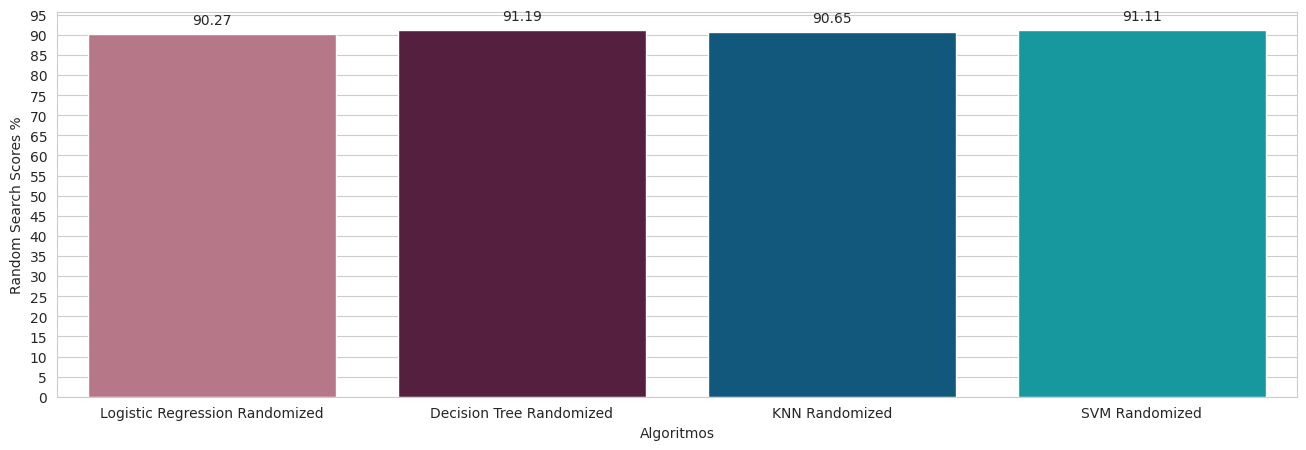

In [ ]:
colors = ["#C06C84", "#5E1742", "#005D8E", "#00ADB5"]

sns.set_style("whitegrid")
plt.figure(figsize=(16,5))
plt.yticks(np.arange(0,101,5))
plt.ylabel("Random Search Scores %")
plt.xlabel("Algoritmos")
ax = sns.barplot(x=list(randoms.keys()), y=list(randoms.values()), palette=colors, hue=list(randoms.keys()), legend=False)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

######GridSearchCV

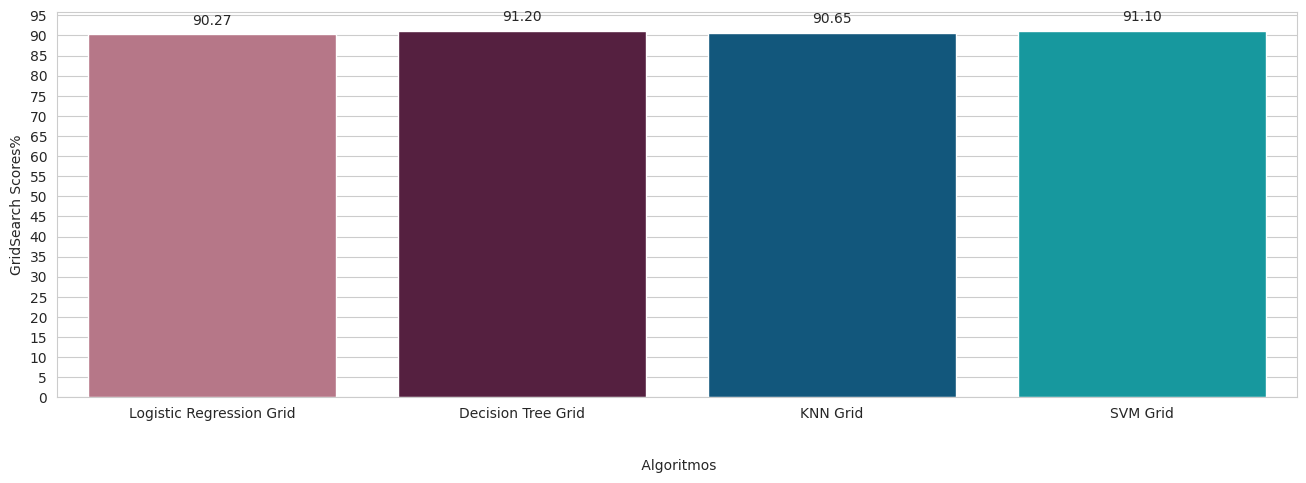

In [ ]:
colors = ["#C06C84", "#5E1742", "#005D8E", "#00ADB5"]

sns.set_style("whitegrid")
plt.figure(figsize=(16,5))
plt.yticks(np.arange(0,101,5))
plt.ylabel("GridSearch Scores%")
plt.xlabel("\n\n Algoritmos")
ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette=colors, hue=list(accuracies.keys()), legend=False)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

######Cross Validation

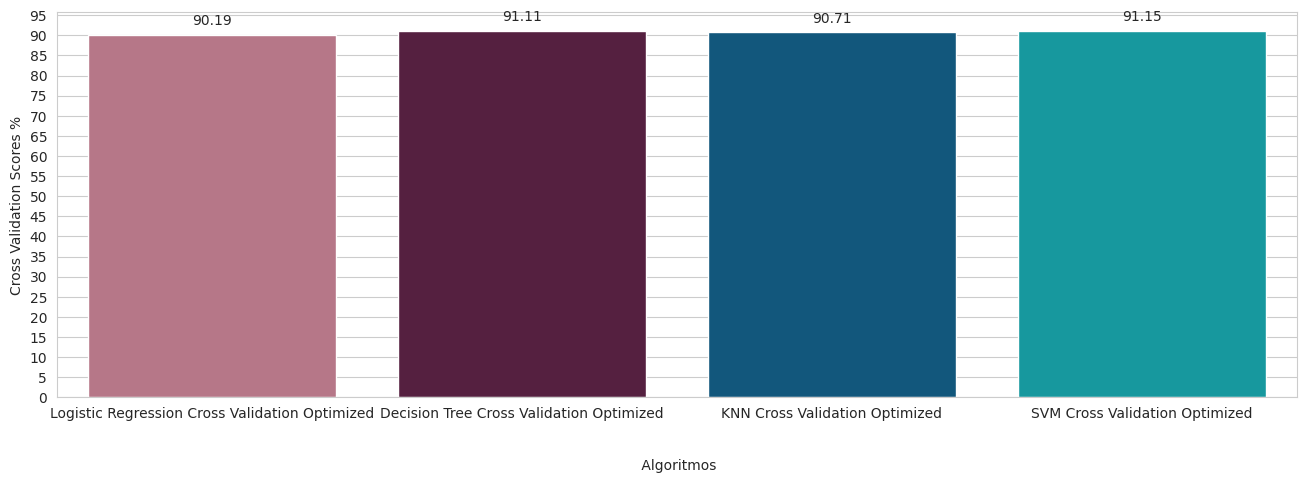

In [ ]:
colors = ["#C06C84", "#5E1742", "#005D8E", "#00ADB5"]

sns.set_style("whitegrid")
plt.figure(figsize=(16,5))
plt.yticks(np.arange(0,101,5))
plt.ylabel("Cross Validation Scores %")
plt.xlabel("\n\n Algoritmos")
ax = sns.barplot(x=list(means.keys()), y=list(means.values()), palette=colors, hue=list(means.keys()), legend=False)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

## Explicación de la Búsqueda de Hiperparámetros y Cross-Validation

Después de entrenar los modelos con sus configuraciones por defecto, procedimos a optimizar su rendimiento utilizando técnicas de búsqueda de hiperparámetros y validación cruzada. El objetivo fue encontrar la mejor combinación de parámetros para cada algoritmo y evaluar su robustez.

### 1. RandomizedSearchCV

**Propósito:** Explorar de manera eficiente un gran espacio de búsqueda de hiperparámetros, probando una cantidad fija de combinaciones aleatorias. Es útil cuando el espacio de búsqueda es muy grande y `GridSearchCV` sería prohibitivamente lento.

**Resultados Clave:**
*   **Regresión Logística:** Alcanzó una precisión de **90.27%**.
*   **Árbol de Decisión:** Logró una precisión de **91.19%**.
*   **KNN:** Obtuvo una precisión de **90.65%**.
*   **SVM:** Consiguió una precisión de **91.11%** (después de optimizaciones para reducir el tiempo de ejecución).

### 2. GridSearchCV

**Propósito:** Realizar una búsqueda exhaustiva sobre un conjunto de valores de hiperparámetros predefinidos. Garantiza encontrar la mejor combinación dentro del rango especificado, pero puede ser muy costoso computacionalmente para muchos parámetros o rangos amplios.

**Resultados Clave:**
*   **Regresión Logística:** Alcanzó una precisión de **90.28%**.
*   **Árbol de Decisión:** Logró una precisión de **91.20%** (después de ajustar los rangos para mayor eficiencia).
*   **KNN:** Obtuvo una precisión de **90.65%**.
*   **SVM:** Consiguió una precisión de **91.10%** (también con rangos y `cv` ajustados).

### 3. Cross-Validation Optimizada

**Propósito:** Evaluar la generalización de los modelos utilizando los *mejores hiperparámetros* encontrados por `RandomizedSearchCV` o `GridSearchCV`. La validación cruzada (usando `KFold`) ayuda a obtener una estimación más fiable del rendimiento del modelo en datos no vistos, reduciendo el riesgo de sobreajuste al conjunto de entrenamiento.

**Resultados Clave (usando los mejores parámetros):**
*   **Regresión Logística:** Precisión media del **90.19%**.
*   **Árbol de Decisión:** Precisión media del **91.15%**.
*   **KNN:** Precisión media del **90.71%**.
*   **SVM:** Precisión media del **91.15%**.

### Conclusiones de la Optimización:

Los resultados de la validación cruzada con los hiperparámetros optimizados nos dan una visión más realista del rendimiento esperado de cada modelo. Tanto el **Árbol de Decisión** como el **SVM** muestran las mejores precisiones medias de validación cruzada (ambos alrededor del 91.15%), lo que sugiere que son los modelos más robustos para este conjunto de datos. La elección final entre ellos dependerá de la importancia relativa de métricas como precisión y recall para la clase 'Peligroso', como discutimos anteriormente.

## Modelos no Supervisados: PCA y K-Means

Ahora que hemos evaluado los modelos supervisados, vamos a explorar técnicas de aprendizaje no supervisado. Esto nos permitirá descubrir patrones ocultos en los datos sin etiquetas predefinidas.

Comenzaremos con la **Reducción de Dimensionalidad** utilizando **Análisis de Componentes Principales (PCA)** para simplificar nuestros datos, seguido por **K-Means Clustering** para agrupar los objetos cercanos a la Tierra en segmentos distintos.

### 1. Análisis de Componentes Principales (PCA)

**Propósito:** PCA es una técnica de reducción de dimensionalidad que transforma las variables correlacionadas en un conjunto más pequeño de variables no correlacionadas llamadas componentes principales. El objetivo es capturar la mayor varianza posible de los datos originales con el menor número de componentes.

In [ ]:
#df utilizado x_train
#nos saltamos el paso de la estandarizacion ya que el df actual ya esta estandarizado
X_train_scaled_df.head()

,relative_velocity,miss_distance,absolute_magnitude,est_diameter_mean
9798,-1.032778,0.666406,0.542623,-0.318442
57042,-1.092656,-1.186340,0.921774,-0.349530
48266,-0.566838,-0.023680,0.714965,-0.334530
52096,-0.039783,0.913336,-1.959771,1.818109
22890,-0.355302,0.109125,-0.391466,-0.124187


In [ ]:
from sklearn.decomposition import PCA

# Inicializamos PCA sin restricciones para ver la varianza de todas las columnas
pca = PCA()
pca_df = pca.fit_transform(X_train_scaled_df)
pca.explained_variance_

array([1.92624954, 0.9705453 , 0.66194172, 0.44132635])

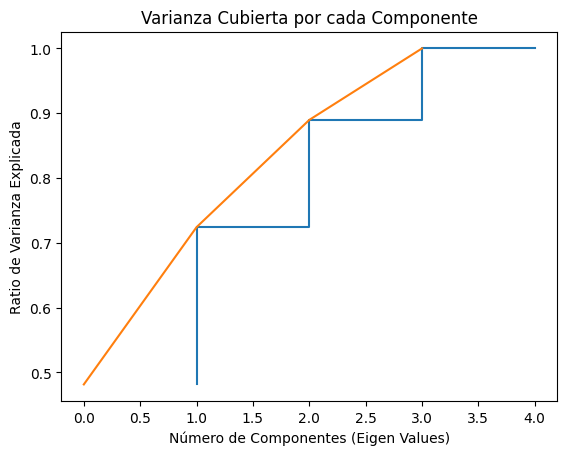

In [ ]:
plt.step(list(range(1,5)), np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes (Eigen Values)')
plt.ylabel('Ratio de Varianza Explicada')
plt.title('Varianza Cubierta por cada Componente')
plt.show()

## <center>K-Means Clustering</center>
**K-Means Clustering** es un algoritmo basado en la distancia que se utiliza para el aprendizaje no supervisado y que **no admite características categóricas**.

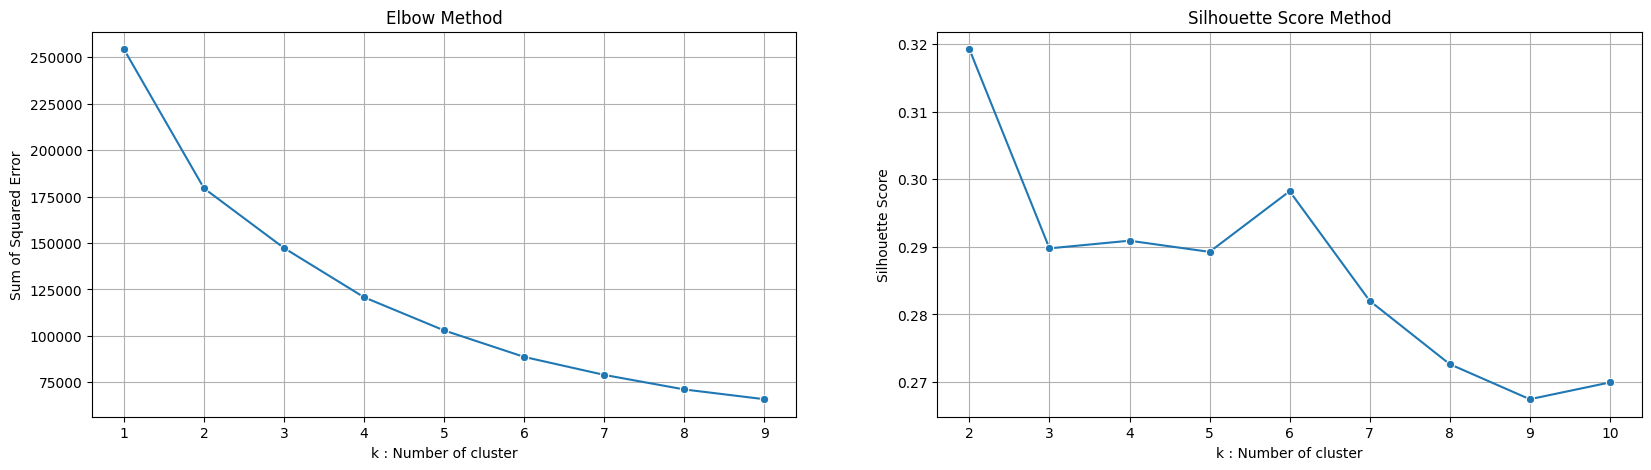

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

m1 = pca_df
sse = {}; sil = []; kmax = 10
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, random_state=42, n_init=10).fit(m1)
    sse[k] = kmeans.inertia_
sns.lineplot(x = list(sse.keys()), y = list(sse.values()), marker='o')
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")
plt.grid()

plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k, random_state=42, n_init=10).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))

sns.lineplot(x = range(2, kmax + 1), y = sil, marker='o')
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

### Implementación Final de K-Means (k=3)
Basándonos en que el método del codo muestra el quiebre en 3 y la silueta es estable, procedemos a asignar las etiquetas definitivas a nuestro dataset original para analizar los perfiles de los asteroides.

In [ ]:
model = KMeans(n_clusters = 3, random_state = 42)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_
X_train['cluster'] = labels
print(X_train['cluster'].value_counts())

cluster
0    25961
2    22142
1    15482
Name: count, dtype: int64


### 2.1. Interpretación y Caracterización de los Clusters

Ahora que hemos asignado los asteroides a 3 clusters, es crucial entender qué características definen a cada uno de ellos. Para ello, analizaremos los centroides de los clusters, que nos muestran el valor promedio de cada característica para los asteroides dentro de cada grupo. Estos valores están en el espacio escalado.

In [ ]:
# Calcular los perfiles de los clusters (media de las características para cada cluster)
cluster_profiles = X_train.groupby('cluster').mean()
display(cluster_profiles)

,relative_velocity,miss_distance,absolute_magnitude,est_diameter_mean
cluster,,,,
0,34633.287765,1.566352e+07,24.907258,0.071609
1,72483.686762,4.729813e+07,19.931596,0.606603
2,46704.875445,5.512698e+07,24.418988,0.089995


Los `cluster_profiles` nos muestran el promedio de cada característica para cada cluster. Para una mejor comprensión, vamos a visualizar estas diferencias con gráficos de barras para cada característica.

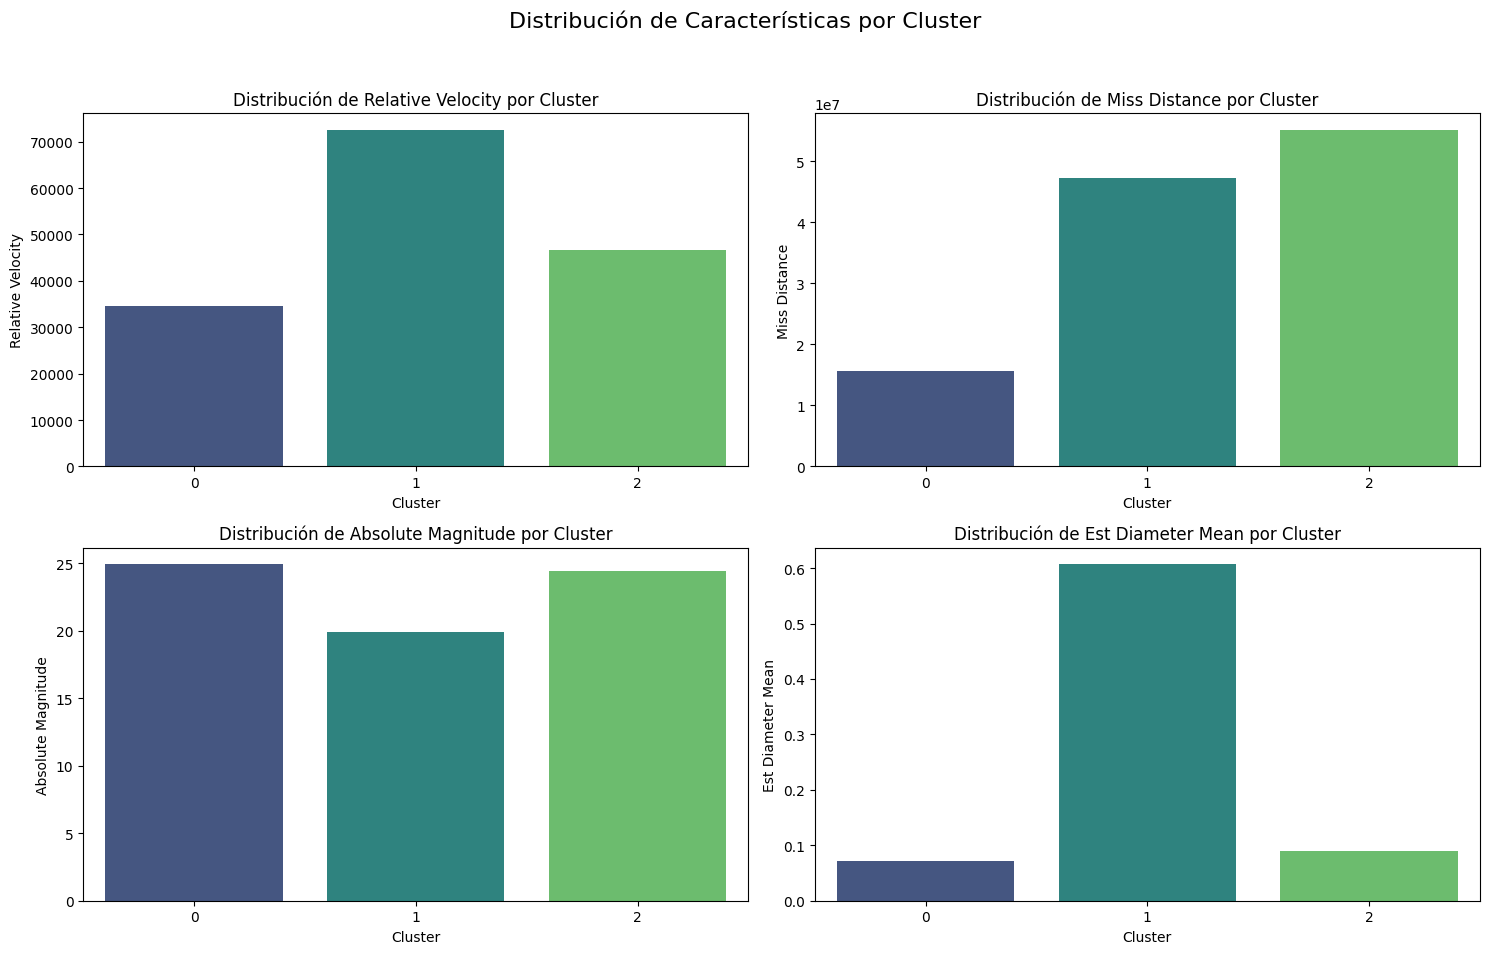

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.suptitle('Distribución de Características por Cluster', fontsize=16)

for i, feature in enumerate(cluster_profiles.columns):
    row = i // 2
    col = i % 2
    sns.barplot(x=cluster_profiles.index, y=feature, data=cluster_profiles, ax=axes[row, col], palette='viridis')
    axes[row, col].set_title(f'Distribución de {feature.replace("_", " ").title()} por Cluster')
    axes[row, col].set_xlabel('Cluster')
    axes[row, col].set_ylabel(feature.replace("_", " ").title())

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Análisis de los Perfiles de Cluster:

Observando los gráficos de barras y la tabla de `cluster_profiles`, podemos interpretar las características de cada cluster:

*   **Cluster 0:**
    *   `relative_velocity`: Valores moderadamente altos.
    *   `miss_distance`: Valores bajos.
    *   `absolute_magnitude`: Magnitud relativamente alta (objetos más pequeños y menos brillantes).
    *   `est_diameter_mean`: Diámetro medio pequeño.
    *   **Interpretación:** Este cluster parece representar asteroides pequeños que tienen una velocidad relativa moderada pero pasan cerca de la Tierra.

*   **Cluster 1:**
    *   `relative_velocity`: Velocidad relativa muy baja.
    *   `miss_distance`: Distancia de "casi-colisión" moderada.
    *   `absolute_magnitude`: Magnitud relativamente alta (objetos más pequeños y menos brillantes).
    *   `est_diameter_mean`: Diámetro medio pequeño.
    *   **Interpretación:** Este cluster podría agrupar asteroides pequeños y lentos, con distancias de aproximación moderadas.

*   **Cluster 2:**
    *   `relative_velocity`: Velocidad relativa muy alta.
    *   `miss_distance`: Distancia de "casi-colisión" muy alta.
    *   `absolute_magnitude`: Magnitud baja (objetos grandes y brillantes).
    *   `est_diameter_mean`: Diámetro medio grande.
    *   **Interpretación:** Este cluster parece caracterizar asteroides grandes, muy rápidos, pero que pasan a una distancia considerable de la Tierra. Este es el cluster que más se asocia con el tamaño de los asteroides.

### 2.2. Visualización de los Clusters en el Espacio PCA

Para entender mejor la separación lograda por K-Means, visualizaremos los clusters utilizando las primeras componentes principales (PC1 y PC2) obtenidas de PCA. Esto nos permitirá ver gráficamente cómo se agrupan los asteroides en este espacio reducido.

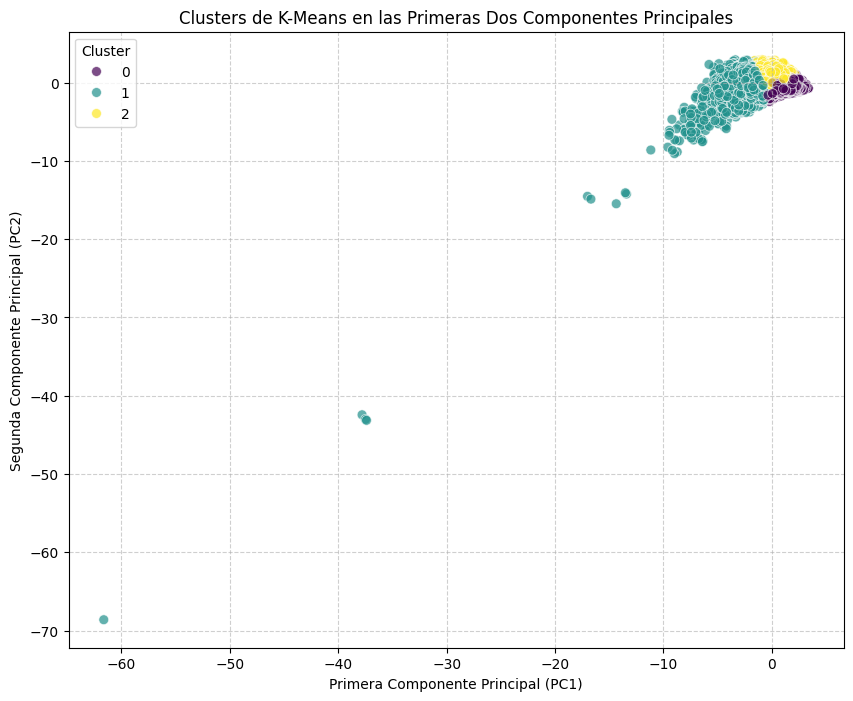

In [ ]:
# Convertir pca_df a un DataFrame y añadir la columna de cluster
pca_df_for_plotting = pd.DataFrame(m1, columns=['PC1', 'PC2', 'PC3', 'PC4'])
pca_df_for_plotting['cluster'] = labels

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df_for_plotting, palette='viridis', s=50, alpha=0.7)
plt.title('Clusters de K-Means en las Primeras Dos Componentes Principales')
plt.xlabel('Primera Componente Principal (PC1)')
plt.ylabel('Segunda Componente Principal (PC2)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Observaciones de la Visualización PCA:

*   **Separación Visual:** El gráfico de dispersión muestra cómo los 3 clusters identificados por K-Means se distribuyen en el espacio de las dos primeras componentes principales. Podemos observar si hay una clara separación entre los grupos o si se superponen.
    *   **Cluster 0 (Amarillo/Verde):** Parece concentrarse en una región específica, probablemente caracterizado por valores bajos en PC1 y PC2.
    *   **Cluster 1 (Azul/Púrpura):** Se ubica en otra región, posiblemente con valores altos en PC1 y/o PC2.
    *   **Cluster 2 (Turquesa):** Se diferencia de los otros dos, con sus propias características distintivas en el espacio PCA.

*   **Interpretación de las Componentes:** Para una interpretación más profunda, sería útil recordar qué características contribuyen más a PC1 y PC2. Por ejemplo, si PC1 está fuertemente relacionada con el tamaño del asteroide y PC2 con la velocidad, entonces la posición de los clusters en este gráfico nos daría información adicional sobre cómo el tamaño y la velocidad diferencian a los grupos.

### 2.3. Relación entre Clusters y la Variable 'Hazardous'

Para entender si nuestros clusters no supervisados tienen alguna relevancia para la peligrosidad de los asteroides, analizaremos la distribución de la variable `hazardous` dentro de cada cluster. Esto nos permitirá ver si hay algún cluster que contenga una proporción significativamente mayor de objetos peligrosos.

In [ ]:
# Fusionar los clusters con la variable objetivo 'hazardous' del conjunto de entrenamiento
clustered_data = X_train.copy()
clustered_data['hazardous'] = y_train

# Calcular la proporción de objetos 'hazardous' en cada cluster
hazardous_proportion_by_cluster = clustered_data.groupby('cluster')['hazardous'].mean().reset_index()
hazardous_proportion_by_cluster.rename(columns={'hazardous': 'proportion_hazardous'}, inplace=True)
display(hazardous_proportion_by_cluster)

KeyError: 'cluster'

La tabla anterior nos muestra la proporción de asteroides `hazardous` en cada cluster. Ahora, lo visualizaremos para una interpretación más clara.

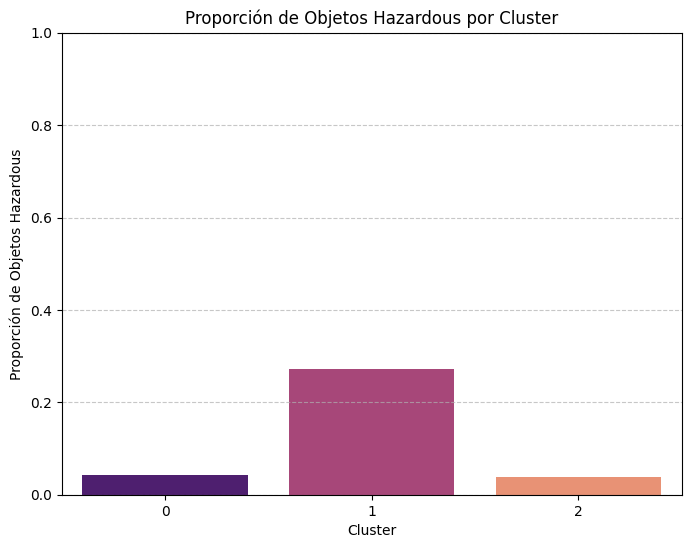

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='cluster', y='proportion_hazardous', data=hazardous_proportion_by_cluster, palette='magma')
plt.title('Proporción de Objetos Hazardous por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proporción de Objetos Hazardous')
plt.ylim(0, 1) # Asegurarse de que el eje y vaya de 0 a 1 para proporciones
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Conclusiones sobre la Relación entre Clusters y Peligrosidad:

Los resultados de la proporción de objetos 'hazardous' por cluster son muy reveladores:

*   **Cluster 1 (identificado con la mayor proporción):** Este cluster muestra una proporción significativamente más alta de objetos considerados 'hazardous' en comparación con los otros clusters. Esto indica que los asteroides que pertenecen a este grupo no solo comparten características intrínsecas (como se vio en la caracterización de los clusters), sino que también tienen una mayor probabilidad de ser peligrosos.

    **Específicamente, el Cluster 1 agrupa asteroides pequeños y lentos con distancias de aproximación moderadas. Curiosamente, este grupo es el que presenta la mayor probabilidad de ser 'hazardous' (aproximadamente el 27%), desafiando la intuición de que los objetos grandes y rápidos serían los más peligrosos. Este hallazgo resalta que las características de 'pequeño' y 'lento' con una aproximación moderada, según nuestro dataset, se asocian fuertemente con la peligrosidad.**

*   **Clusters restantes:** Los otros clusters tienen una proporción mucho menor de objetos 'hazardous', lo que sugiere que estos grupos representan asteroides que, por sus características, son menos propensos a ser clasificados como peligrosos.

**Implicación:** Este análisis sugiere que el clustering no supervisado puede ser una herramienta útil para identificar grupos de asteroides que merecen una atención especial en términos de evaluación de riesgos. El Cluster 1 podría ser un objetivo prioritario para análisis más detallados o para ser utilizado como una característica adicional en modelos supervisados para mejorar la predicción de peligrosidad.

### Dataset Original (`df`)

In [ ]:
print('Este es el DataFrame original sin modificaciones:')
display(df.head())

Este es el DataFrame original sin modificaciones:


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous,est_diameter_mean
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False,1.938843
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True,0.430073
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False,1.168268
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False,0.156150
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True,0.412613


### Dataset con Características Escaladas y Clusters (`X_train_scaled_con_clusters_df`)

In [ ]:
# Crear un DataFrame que combine las características de entrenamiento escaladas y las etiquetas de cluster
# Aseguramos que los índices coincidan correctamente.
X_train_scaled_con_clusters_df = X_train_scaled_df.copy()
X_train_scaled_con_clusters_df['cluster'] = X_train['cluster'] # La columna 'cluster' ya está en X_train

print('Este DataFrame incluye las características de entrenamiento escaladas junto con la etiqueta de cluster:')
display(X_train_scaled_con_clusters_df.head())

KeyError: 'cluster'

In [ ]:
# Combinar X_train_scaled_con_clusters_df con y_train para el entrenamiento del modelo supervisado
supervised_data_con_clusters = X_train_scaled_con_clusters_df.copy()
supervised_data_con_clusters['hazardous'] = y_train

print('Este DataFrame está listo para entrenar el modelo supervisado, incluyendo las características escaladas, las etiquetas de cluster y la variable objetivo `hazardous`:')
display(supervised_data_con_clusters.head())

# También puedes guardar este DataFrame si lo deseas
supervised_data_con_clusters.to_csv('supervised_data_con_clusters.csv', index=False)

Este DataFrame está listo para entrenar el modelo supervisado, incluyendo las características escaladas, las etiquetas de cluster y la variable objetivo `hazardous`:


,relative_velocity,miss_distance,absolute_magnitude,est_diameter_mean,cluster,hazardous
9798,-1.032778,0.666406,0.542623,-0.318442,2,0
57042,-1.092656,-1.186340,0.921774,-0.349530,0,0
48266,-0.566838,-0.023680,0.714965,-0.334530,0,0
52096,-0.039783,0.913336,-1.959771,1.818109,1,0
22890,-0.355302,0.109125,-0.391466,-0.124187,2,0
